In [ ]:
#libaries
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

In [3]:
DATA_PATH = Path("Data")

print("Data folder exists:", DATA_PATH.exists())
print("Full path:", DATA_PATH.resolve())

Data folder exists: True
Full path: D:\Data Science\Projects\Final Project\Data


In [4]:
csv_files = sorted(DATA_PATH.glob("*.csv"))

print(f"Number of CSV files: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files: 9
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [ ]:
#load data
datasets = {}

for file in csv_files:
    dataset_name = file.stem
    
    datasets[dataset_name] = pd.read_csv(
        file,
        low_memory=False
    )
    
    print(f"Loaded: {dataset_name}")

Loaded: olist_customers_dataset
Loaded: olist_geolocation_dataset
Loaded: olist_order_items_dataset
Loaded: olist_order_payments_dataset
Loaded: olist_order_reviews_dataset
Loaded: olist_orders_dataset
Loaded: olist_products_dataset
Loaded: olist_sellers_dataset
Loaded: product_category_name_translation


In [7]:
#short-names of data
customers = datasets["olist_customers_dataset"]
geolocation = datasets["olist_geolocation_dataset"]
order_items = datasets["olist_order_items_dataset"]
payments = datasets["olist_order_payments_dataset"]
reviews = datasets["olist_order_reviews_dataset"]
orders = datasets["olist_orders_dataset"]
products = datasets["olist_products_dataset"]
sellers = datasets["olist_sellers_dataset"]
category_translation = datasets["product_category_name_translation"]

In [9]:
dataset_summary = []

for name, dataframe in datasets.items():
    dataset_summary.append({
        "dataset": name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "duplicate_rows": dataframe.duplicated().sum(),
        "missing_values": dataframe.isnull().sum().sum()
    })

dataset_summary_df = pd.DataFrame(dataset_summary)

dataset_summary_df.sort_values(
    by="rows",
    ascending=False
).reset_index(drop=True)

,dataset,rows,columns,duplicate_rows,missing_values
0,olist_geolocation_dataset,1000163,5,261831,0
1,olist_order_items_dataset,112650,7,0,0
2,olist_order_payments_dataset,103886,5,0,0
3,olist_customers_dataset,99441,5,0,0
4,olist_orders_dataset,99441,8,0,4908
5,olist_order_reviews_dataset,99224,7,0,145903
6,olist_products_dataset,32951,9,0,2448
7,olist_sellers_dataset,3095,4,0,0
8,product_category_name_translation,71,2,0,0


In [11]:
display(orders.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [13]:
display(
    orders.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

,missing_values
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160
order_id,0
order_purchase_timestamp,0
order_status,0
customer_id,0
order_estimated_delivery_date,0


In [14]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Data Cleaning

### Investigating Missing Values in the Orders Dataset

The missing values in the delivery-date columns should not be removed immediately because they may be associated with canceled, unavailable, shipped, or undelivered orders.

Therefore, the order-status distribution will be investigated before handling the missing values.

In [15]:
# Check the distribution of order statuses

order_status_summary = (
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="number_of_orders")
)

order_status_summary["percentage"] = (
    order_status_summary["number_of_orders"]
    / len(orders)
    * 100
).round(2)

display(order_status_summary)

,order_status,number_of_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [16]:
# Investigate missing values by order status

missing_by_status = (
    orders.groupby("order_status")
    .agg(
        total_orders=("order_id", "count"),

        missing_approved_date=(
            "order_approved_at",
            lambda column: column.isna().sum()
        ),

        missing_carrier_delivery_date=(
            "order_delivered_carrier_date",
            lambda column: column.isna().sum()
        ),

        missing_customer_delivery_date=(
            "order_delivered_customer_date",
            lambda column: column.isna().sum()
        )
    )
    .sort_values("total_orders", ascending=False)
)

display(missing_by_status)

,total_orders,missing_approved_date,missing_carrier_delivery_date,missing_customer_delivery_date
order_status,,,,
delivered,96478,14,2,8
shipped,1107,0,0,1107
canceled,625,141,550,619
unavailable,609,0,609,609
invoiced,314,0,314,314
processing,301,0,301,301
created,5,5,5,5
approved,2,0,2,2


### Correcting Date Column Data Types

The order date columns were initially loaded as text values.  
They are converted to datetime format to enable valid date comparisons and time-based feature engineering.

Invalid date values are converted to missing values using `errors="coerce"` so they can be investigated later.

In [17]:
# List of date columns in the orders dataset

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Convert date columns from object to datetime

for column in order_date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

In [18]:
orders[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [19]:
orders[order_date_columns].isnull().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Selecting Valid Delivered Orders and Creating the Target

The project aims to predict whether a delivered order arrived later than its estimated delivery date.

Only orders with:
- `order_status = delivered`
- a valid actual delivery date
- a valid estimated delivery date

will be used to create the target.

The target variable is:

- `0` = Delivered on time
- `1` = Delivered late

In [20]:
# Select only completed delivered orders with valid delivery dates

delivered_orders = orders.loc[
    (orders["order_status"] == "delivered")
    & orders["order_delivered_customer_date"].notna()
    & orders["order_estimated_delivery_date"].notna()
].copy()

In [21]:
print("Total orders:", orders.shape[0])
print("Valid delivered orders:", delivered_orders.shape[0])
print("Removed orders:", orders.shape[0] - delivered_orders.shape[0])

Total orders: 99441
Valid delivered orders: 96470
Removed orders: 2971


In [22]:
# Normalize dates to compare delivery days without considering time

actual_delivery_date = (
    delivered_orders["order_delivered_customer_date"]
    .dt.normalize()
)

estimated_delivery_date = (
    delivered_orders["order_estimated_delivery_date"]
    .dt.normalize()
)

# Create binary target

delivered_orders["is_late"] = (
    actual_delivery_date > estimated_delivery_date
).astype("int8")    

In [23]:
target_distribution = (
    delivered_orders["is_late"]
    .value_counts()
    .sort_index()
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_distribution["label"] = target_distribution["is_late"].map({
    0: "On Time",
    1: "Late"
})

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
    * 100
).round(2)

display(target_distribution)

,is_late,count,label,percentage
0,0,89936,On Time,93.23
1,1,6534,Late,6.77


In [24]:
delivered_orders[
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "is_late"
    ]
].head(10)

,order_delivered_customer_date,order_estimated_delivery_date,is_late
0,2017-10-10 21:25:13,2017-10-18,0
1,2018-08-07 15:27:45,2018-08-13,0
2,2018-08-17 18:06:29,2018-09-04,0
3,2017-12-02 00:28:42,2017-12-15,0
4,2018-02-16 18:17:02,2018-02-26,0
5,2017-07-26 10:57:55,2017-08-01,0
7,2017-05-26 12:55:51,2017-06-07,0
8,2017-02-02 14:08:10,2017-03-06,0
9,2017-08-16 17:14:30,2017-08-23,0
10,2017-05-29 11:18:31,2017-06-07,0


In [26]:
delivered_orders.loc[
    delivered_orders["is_late"] == 1,
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "is_late"
    ]
].head(10)

,order_delivered_customer_date,order_estimated_delivery_date,is_late
20,2017-10-09 22:23:46,2017-09-28,1
25,2018-03-21 22:03:54,2018-03-12,1
41,2017-12-28 18:59:23,2017-12-21,1
57,2018-04-03 13:28:46,2018-04-02,1
58,2017-04-06 13:37:16,2017-03-30,1
97,2017-12-28 19:43:00,2017-12-11,1
102,2018-08-03 19:28:47,2018-08-02,1
110,2018-01-23 21:38:52,2017-12-22,1
115,2018-01-20 13:42:22,2017-12-19,1
143,2018-03-22 00:03:53,2018-03-16,1


### Creating Time-Based Features

Several features are extracted from the purchase timestamp to help the model identify seasonal and temporal delivery patterns.

The actual customer delivery date is used only to create the target and will not be used as a model feature because that would cause data leakage.

In [27]:
# Reset the index after filtering delivered orders

delivered_orders.reset_index(drop=True, inplace=True)


# Create time-based features from the purchase timestamp

delivered_orders["purchase_year"] = (
    delivered_orders["order_purchase_timestamp"].dt.year
)

delivered_orders["purchase_month"] = (
    delivered_orders["order_purchase_timestamp"].dt.month
)

delivered_orders["purchase_day_of_week"] = (
    delivered_orders["order_purchase_timestamp"].dt.dayofweek
)

delivered_orders["purchase_hour"] = (
    delivered_orders["order_purchase_timestamp"].dt.hour
)

delivered_orders["is_weekend"] = (
    delivered_orders["purchase_day_of_week"]
    .isin([5, 6])
    .astype("int8")
)

In [28]:
# Number of days promised for delivery

delivered_orders["promised_delivery_days"] = (
    delivered_orders["order_estimated_delivery_date"].dt.normalize()
    - delivered_orders["order_purchase_timestamp"].dt.normalize()
).dt.days

In [29]:
display(
    delivered_orders[
        [
            "order_purchase_timestamp",
            "order_estimated_delivery_date",
            "purchase_year",
            "purchase_month",
            "purchase_day_of_week",
            "purchase_hour",
            "is_weekend",
            "promised_delivery_days",
            "is_late"
        ]
    ].head(10)
)

,order_purchase_timestamp,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,is_weekend,promised_delivery_days,is_late
0,2017-10-02 10:56:33,2017-10-18,2017,10,0,10,0,16,0
1,2018-07-24 20:41:37,2018-08-13,2018,7,1,20,0,20,0
2,2018-08-08 08:38:49,2018-09-04,2018,8,2,8,0,27,0
3,2017-11-18 19:28:06,2017-12-15,2017,11,5,19,1,27,0
4,2018-02-13 21:18:39,2018-02-26,2018,2,1,21,0,13,0
5,2017-07-09 21:57:05,2017-08-01,2017,7,6,21,1,23,0
6,2017-05-16 13:10:30,2017-06-07,2017,5,1,13,0,22,0
7,2017-01-23 18:29:09,2017-03-06,2017,1,0,18,0,42,0
8,2017-07-29 11:55:02,2017-08-23,2017,7,5,11,1,25,0
9,2017-05-16 19:41:10,2017-06-07,2017,5,1,19,0,22,0


In [30]:
delivered_orders["promised_delivery_days"].describe()

count    96470.000000
mean        24.372738
std          8.758428
min          3.000000
25%         19.000000
50%         24.000000
75%         29.000000
max        156.000000
Name: promised_delivery_days, dtype: float64

In [31]:
print(
    "Zero or negative promised delivery days:",
    (delivered_orders["promised_delivery_days"] <= 0).sum()
)

Zero or negative promised delivery days: 0


### Inspecting the Payments Dataset Before Merging

An order may have more than one payment record because customers can use multiple payment methods or payment sequences.

Therefore, the payments dataset must be inspected and aggregated before merging it with the orders dataset to ensure that each order appears only once.

In [32]:
# Inspect the payments dataset

print("Payments dataset shape:", payments.shape)

print(
    "Fully duplicated rows:",
    payments.duplicated().sum()
)

print(
    "Repeated order IDs:",
    payments["order_id"].duplicated().sum()
)

print(
    "Missing values:",
    payments.isnull().sum().sum()
)

display(payments.head())

Payments dataset shape: (103886, 5)
Fully duplicated rows: 0
Repeated order IDs: 4446
Missing values: 0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [33]:
payment_records_per_order = (
    payments.groupby("order_id")
    .size()
    .sort_values(ascending=False)
)

display(payment_records_per_order.head(10))

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
4bfcba9e084f46c8e3cb49b0fa6e6159    15
21577126c19bf11a0b91592e5844ba78    15
4689b1816de42507a7d63a4617383c59    14
3c58bffb70dcf45f12bdf66a3c215905    14
dtype: int64

### Aggregating Payment Records

The payments dataset contains multiple records for some orders because an order may have multiple payment sequences or payment methods.

The records are aggregated by `order_id` before merging to ensure that each order appears only once in the final modeling dataset.

In [34]:
# Return the most frequent value in a column

def mode_or_first(series):
    modes = series.mode(dropna=True)

    if not modes.empty:
        return modes.iloc[0]

    return np.nan

In [35]:
payments_aggregated = (
    payments.groupby("order_id")
    .agg(
        total_payment_value=(
            "payment_value",
            "sum"
        ),

        maximum_installments=(
            "payment_installments",
            "max"
        ),

        payment_records_count=(
            "payment_sequential",
            "count"
        ),

        unique_payment_types=(
            "payment_type",
            "nunique"
        ),

        main_payment_type=(
            "payment_type",
            mode_or_first
        )
    )
    .reset_index()
)

In [36]:
display(payments_aggregated.head(10))

print(
    "Aggregated payments shape:",
    payments_aggregated.shape
)

,order_id,total_payment_value,maximum_installments,payment_records_count,unique_payment_types,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,1,credit_card
5,00048cc3ae777c65dbb7d2a0634bc1ea,34.59,1,1,1,boleto
6,00054e8431b9d7675808bcb819fb4a32,31.75,1,1,1,credit_card
7,000576fe39319847cbb9d288c5617fa6,880.75,10,1,1,credit_card
8,0005a1a1728c9d785b8e2b08b904576c,157.60,3,1,1,credit_card
9,0005f50442cb953dcd1d21e1fb923495,65.39,1,1,1,credit_card


Aggregated payments shape: (99440, 6)


In [37]:
print(
    "Duplicated order IDs after aggregation:",
    payments_aggregated["order_id"].duplicated().sum()
)

Duplicated order IDs after aggregation: 0


In [38]:
payments_aggregated.isnull().sum()

order_id                 0
total_payment_value      0
maximum_installments     0
payment_records_count    0
unique_payment_types     0
main_payment_type        0
dtype: int64

### Inspecting the Order Items Dataset Before Merging

The `order_items` dataset may contain multiple rows for the same order because one order can include multiple products or sellers.

Therefore, the dataset must be inspected and later aggregated to ensure that each order appears only once in the final modeling dataset.

In [39]:
# Inspect the order items dataset

print("Order items dataset shape:", order_items.shape)

print(
    "Fully duplicated rows:",
    order_items.duplicated().sum()
)

print(
    "Repeated order IDs:",
    order_items["order_id"].duplicated().sum()
)

print(
    "Missing values:",
    order_items.isnull().sum().sum()
)

display(order_items.head())

Order items dataset shape: (112650, 7)
Fully duplicated rows: 0
Repeated order IDs: 13984
Missing values: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [40]:
items_per_order = (
    order_items.groupby("order_id")
    .size()
    .sort_values(ascending=False)
)

display(items_per_order.head(10))

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
af822dacd6f5cff7376413c03a388bb7    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
dtype: int64

In [41]:
display(
    order_items[
        [
            "price",
            "freight_value",
            "order_item_id"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00


In [42]:
order_items_quality_checks = {
    "zero_or_negative_price":
        (order_items["price"] <= 0).sum(),

    "negative_freight_value":
        (order_items["freight_value"] < 0).sum(),

    "zero_or_negative_item_id":
        (order_items["order_item_id"] <= 0).sum()
}

display(
    pd.Series(
        order_items_quality_checks,
        name="count"
    )
)

zero_or_negative_price      0
negative_freight_value      0
zero_or_negative_item_id    0
Name: count, dtype: int64

### Correcting Inconsistent Column Names

The products dataset contains misspelled column names: `product_name_lenght` and `product_description_lenght`.

These columns are renamed to improve code readability and maintain consistent naming conventions.

In [47]:
# Correct misspelled column names

products.rename(
    columns={
        "product_name_lenght": "product_name_length",
        "product_description_lenght": "product_description_length"
    },
    inplace=True
)

In [48]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_length',
 'product_description_length',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

### Inspecting the Products Dataset

The products dataset is inspected before merging because it contains missing values in product categories, weights, dimensions, and description-related columns.

The missing and invalid values will be investigated before selecting an appropriate cleaning method.

In [49]:
# Inspect the products dataset

print("Products dataset shape:", products.shape)

print(
    "Fully duplicated rows:",
    products.duplicated().sum()
)

print(
    "Duplicated product IDs:",
    products["product_id"].duplicated().sum()
)

display(products.head())

Products dataset shape: (32951, 9)
Fully duplicated rows: 0
Duplicated product IDs: 0


,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [50]:
products_missing_report = pd.DataFrame({
    "missing_count": products.isnull().sum(),
    "missing_percentage": (
        products.isnull().mean() * 100
    ).round(2)
})

products_missing_report = products_missing_report[
    products_missing_report["missing_count"] > 0
].sort_values(
    "missing_count",
    ascending=False
)

display(products_missing_report)

,missing_count,missing_percentage
product_category_name,610,1.85
product_name_length,610,1.85
product_description_length,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [51]:
product_numeric_columns = [
    "product_name_length",
    "product_description_length",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

display(
    products[product_numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
product_name_length,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_length,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


In [52]:
product_quality_checks = {
    "zero_or_negative_weight":
        (products["product_weight_g"] <= 0).sum(),

    "zero_or_negative_length":
        (products["product_length_cm"] <= 0).sum(),

    "zero_or_negative_height":
        (products["product_height_cm"] <= 0).sum(),

    "zero_or_negative_width":
        (products["product_width_cm"] <= 0).sum(),

    "negative_photos_quantity":
        (products["product_photos_qty"] < 0).sum()
}

display(
    pd.Series(
        product_quality_checks,
        name="count"
    )
)

zero_or_negative_weight     4
zero_or_negative_length     0
zero_or_negative_height     0
zero_or_negative_width      0
negative_photos_quantity    0
Name: count, dtype: int64

### Handling Missing Values in the Products Dataset

The missing product metadata represents a small percentage of the dataset.

The following cleaning decisions are applied:

- Missing product categories are labeled as `unknown`.
- Missing name length, description length, and photo quantity are filled with zero because the product metadata is unavailable.
- A binary feature is created to indicate whether product metadata was originally missing.
- Missing product weight and dimensions are filled using the median of the corresponding product category, followed by the overall median if necessary.

Rows are not removed because the missing percentage is small and the products may still contain useful order information.

In [53]:
# Create a copy to preserve the original products dataset

products_clean = products.copy()

In [54]:
metadata_columns = [
    "product_category_name",
    "product_name_length",
    "product_description_length",
    "product_photos_qty"
]

products_clean["missing_product_metadata"] = (
    products_clean[metadata_columns]
    .isnull()
    .any(axis=1)
    .astype("int8")
)

In [55]:
# Replace missing category names

products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("unknown")
)


# Replace missing descriptive metadata

descriptive_columns = [
    "product_name_length",
    "product_description_length",
    "product_photos_qty"
]

products_clean[descriptive_columns] = (
    products_clean[descriptive_columns]
    .fillna(0)
)

In [56]:
physical_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in physical_columns:
    
    # First, use the median of the product category
    category_median = (
        products_clean.groupby("product_category_name")[column]
        .transform("median")
    )
    
    products_clean[column] = (
        products_clean[column]
        .fillna(category_median)
    )
    
    # If still missing, use the overall median
    products_clean[column] = (
        products_clean[column]
        .fillna(products_clean[column].median())
    )

In [57]:
products_clean["product_volume_cm3"] = (
    products_clean["product_length_cm"]
    * products_clean["product_height_cm"]
    * products_clean["product_width_cm"]
)

In [58]:
products_clean.isnull().sum()

product_id                    0
product_category_name         0
product_name_length           0
product_description_length    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
missing_product_metadata      0
product_volume_cm3            0
dtype: int64

In [59]:
print(
    "Missing values before cleaning:",
    products.isnull().sum().sum()
)

print(
    "Missing values after cleaning:",
    products_clean.isnull().sum().sum()
)

Missing values before cleaning: 2448
Missing values after cleaning: 0


In [60]:
display(
    products_clean[
        [
            "product_category_name",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm",
            "product_volume_cm3",
            "missing_product_metadata"
        ]
    ].head()
)

,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,missing_product_metadata
0,perfumaria,225.0,16.0,10.0,14.0,2240.0,0
1,artes,1000.0,30.0,18.0,20.0,10800.0,0
2,esporte_lazer,154.0,18.0,9.0,15.0,2430.0,0
3,bebes,371.0,26.0,4.0,26.0,2704.0,0
4,utilidades_domesticas,625.0,20.0,17.0,13.0,4420.0,0


### Cleaning and Merging Product Category Translations

The product-category translation dataset is inspected for missing values and duplicated category names.

It is then merged with the cleaned products dataset to provide English category names that are easier to interpret during analysis and deployment.

In [61]:
print("Translation dataset shape:", category_translation.shape)

print(
    "Fully duplicated rows:",
    category_translation.duplicated().sum()
)

print(
    "Duplicated category names:",
    category_translation["product_category_name"].duplicated().sum()
)

print(
    "Missing values:",
    category_translation.isnull().sum().sum()
)

display(category_translation.head(10))

Translation dataset shape: (71, 2)
Fully duplicated rows: 0
Duplicated category names: 0
Missing values: 0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [62]:
category_translation_clean = category_translation.copy()

category_translation_clean["product_category_name"] = (
    category_translation_clean["product_category_name"]
    .astype("string")
    .str.strip()
)

category_translation_clean["product_category_name_english"] = (
    category_translation_clean["product_category_name_english"]
    .astype("string")
    .str.strip()
)

In [63]:
products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .astype("string")
    .str.strip()
)

In [64]:
products_clean = products_clean.merge(
    category_translation_clean,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

In [65]:
validate="many_to_one"

In [66]:
products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"]
    .fillna("unknown")
)

In [67]:
print(
    "Products shape after translation merge:",
    products_clean.shape
)

print(
    "Missing English categories:",
    products_clean["product_category_name_english"]
    .isnull()
    .sum()
)

print(
    "Duplicated product IDs:",
    products_clean["product_id"]
    .duplicated()
    .sum()
)

Products shape after translation merge: (32951, 12)
Missing English categories: 0
Duplicated product IDs: 0


In [68]:
display(
    products_clean[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english",
            "product_weight_g",
            "product_volume_cm3"
        ]
    ].head(10)
)

,product_id,product_category_name,product_category_name_english,product_weight_g,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,225.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,1000.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,154.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,371.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,625.0,4420.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments,200.0,2090.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff,18350.0,73920.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor,900.0,12800.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances,400.0,5967.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys,600.0,2040.0


### Inspecting and Cleaning the Sellers Dataset

The sellers dataset is inspected for duplicated seller IDs, missing values, and inconsistent categorical text before merging it with the order-items dataset.

Each seller should appear only once because the relationship between order items and sellers is many-to-one.

In [69]:
# Inspect the sellers dataset

print("Sellers dataset shape:", sellers.shape)

print(
    "Fully duplicated rows:",
    sellers.duplicated().sum()
)

print(
    "Duplicated seller IDs:",
    sellers["seller_id"].duplicated().sum()
)

print(
    "Total missing values:",
    sellers.isnull().sum().sum()
)

display(sellers.head(10))

Sellers dataset shape: (3095, 4)
Fully duplicated rows: 0
Duplicated seller IDs: 0
Total missing values: 0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
5,c240c4061717ac1806ae6ee72be3533b,20920,rio de janeiro,RJ
6,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE
7,1b938a7ec6ac5061a66a3766e0e75f90,16304,penapolis,SP
8,768a86e36ad6aae3d03ee3c6433d61df,1529,sao paulo,SP
9,ccc4bbb5f32a6ab2b7066a4130f114e3,80310,curitiba,PR


In [70]:
sellers_clean = sellers.copy()

In [71]:
text_columns = [
    "seller_city",
    "seller_state"
]

for column in text_columns:
    sellers_clean[column] = (
        sellers_clean[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

In [72]:
print(
    "Number of seller states:",
    sellers_clean["seller_state"].nunique()
)

print(
    "Number of seller cities:",
    sellers_clean["seller_city"].nunique()
)

display(
    sellers_clean["seller_state"]
    .value_counts()
    .head(10)
)

Number of seller states: 23
Number of seller cities: 611


seller_state
sp    1849
pr     349
mg     244
sc     190
rj     171
rs     129
go      40
df      30
es      23
ba      19
Name: count, dtype: Int64

In [73]:
assert sellers_clean["seller_id"].is_unique, \
    "Seller IDs must be unique."

print("Sellers cleaning completed successfully.")

Sellers cleaning completed successfully.


### Merging Order Items with Product and Seller Data

Each row in the order-items dataset represents one item purchased within an order.

Each order item is linked to:
- one product through `product_id`
- one seller through `seller_id`

The cleaned product and seller datasets are merged using many-to-one validation to prevent accidental row duplication.

The number of rows should remain unchanged after both merges.

In [74]:
# Create a clean copy of the order-items dataset

order_items_clean = order_items.copy()


# Convert the shipping-limit column to datetime

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"],
    errors="coerce"
)

In [75]:
print(
    "Shipping limit data type:",
    order_items_clean["shipping_limit_date"].dtype
)

print(
    "Missing shipping-limit dates:",
    order_items_clean["shipping_limit_date"].isnull().sum()
)

Shipping limit data type: datetime64[ns]
Missing shipping-limit dates: 0


In [76]:
items_enriched = order_items_clean.merge(
    products_clean,
    on="product_id",
    how="left",
    validate="many_to_one",
    indicator="product_merge_status"
)

In [77]:
items_enriched = items_enriched.merge(
    sellers_clean,
    on="seller_id",
    how="left",
    validate="many_to_one",
    indicator="seller_merge_status"
)

In [78]:
print(
    "Order items rows before merging:",
    order_items_clean.shape[0]
)

print(
    "Rows after merging:",
    items_enriched.shape[0]
)

print("\nProduct merge result:")
display(
    items_enriched["product_merge_status"]
    .value_counts(dropna=False)
)

print("\nSeller merge result:")
display(
    items_enriched["seller_merge_status"]
    .value_counts(dropna=False)
)

Order items rows before merging: 112650
Rows after merging: 112650

Product merge result:


product_merge_status
both          112650
left_only          0
right_only         0
Name: count, dtype: int64


Seller merge result:


seller_merge_status
both          112650
left_only          0
right_only         0
Name: count, dtype: int64

In [79]:
print(
    "Duplicated order-item combinations:",
    items_enriched.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Duplicated order-item combinations: 0


In [80]:
assert items_enriched.shape[0] == order_items_clean.shape[0], \
    "The merge changed the number of order-item rows."

assert (
    items_enriched.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum() == 0
), "Duplicated order items were created during merging."

In [81]:
items_enriched.drop(
    columns=[
        "product_merge_status",
        "seller_merge_status"
    ],
    inplace=True
)

display(items_enriched.head())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,missing_product_metadata,product_volume_cm3,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,0,3528.0,cool_stuff,27277,volta redonda,sp
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,0,60000.0,pet_shop,3471,sao paulo,sp
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,0,14157.0,furniture_decor,37564,borda da mata,mg
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,0,2400.0,perfumery,14403,franca,sp
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,0,42000.0,garden_tools,87900,loanda,pr


### Aggregating Order Items at the Order Level

An order may contain multiple items, products, categories, or sellers.

Because the prediction target is defined at the order level, the enriched order-items dataset is aggregated so that each `order_id` appears exactly once.

New order-level features are created, including item count, total price, total freight cost, total product weight, total product volume, and the number of unique products and sellers.

In [82]:
def mode_or_first(series):
    modes = series.mode(dropna=True)

    if not modes.empty:
        return modes.iloc[0]

    return np.nan

In [83]:
items_aggregated = (
    items_enriched.groupby("order_id")
    .agg(
        item_count=(
            "order_item_id",
            "count"
        ),

        unique_products=(
            "product_id",
            "nunique"
        ),

        unique_sellers=(
            "seller_id",
            "nunique"
        ),

        unique_product_categories=(
            "product_category_name_english",
            "nunique"
        ),

        total_item_price=(
            "price",
            "sum"
        ),

        average_item_price=(
            "price",
            "mean"
        ),

        total_freight_value=(
            "freight_value",
            "sum"
        ),

        total_product_weight_g=(
            "product_weight_g",
            "sum"
        ),

        total_product_volume_cm3=(
            "product_volume_cm3",
            "sum"
        ),

        main_product_category=(
            "product_category_name_english",
            mode_or_first
        ),

        main_seller_state=(
            "seller_state",
            mode_or_first
        ),

        any_missing_product_metadata=(
            "missing_product_metadata",
            "max"
        )
    )
    .reset_index()
)

In [84]:
print(
    "Rows before aggregation:",
    items_enriched.shape[0]
)

print(
    "Unique orders before aggregation:",
    items_enriched["order_id"].nunique()
)

print(
    "Rows after aggregation:",
    items_aggregated.shape[0]
)

display(items_aggregated.head(10))

Rows before aggregation: 112650
Unique orders before aggregation: 98666
Rows after aggregation: 98666


,order_id,item_count,unique_products,unique_sellers,unique_product_categories,total_item_price,average_item_price,total_freight_value,total_product_weight_g,total_product_volume_cm3,main_product_category,main_seller_state,any_missing_product_metadata
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,1,58.90,58.90,13.29,650.0,3528.0,cool_stuff,sp,0
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,1,239.90,239.90,19.93,30000.0,60000.0,pet_shop,sp,0
2,000229ec398224ef6ca0657da4fc703e,1,1,1,1,199.00,199.00,17.87,3050.0,14157.0,furniture_decor,mg,0
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,1,12.99,12.99,12.79,200.0,2400.0,perfumery,sp,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,1,199.90,199.90,18.14,3750.0,42000.0,garden_tools,pr,0
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,1,1,1,21.90,21.90,12.69,450.0,2880.0,housewares,sp,0
6,00054e8431b9d7675808bcb819fb4a32,1,1,1,1,19.90,19.90,11.85,200.0,2700.0,telephony,sp,0
7,000576fe39319847cbb9d288c5617fa6,1,1,1,1,810.00,810.00,70.75,13805.0,118125.0,garden_tools,sp,0
8,0005a1a1728c9d785b8e2b08b904576c,1,1,1,1,145.95,145.95,11.65,2000.0,5760.0,health_beauty,sp,0
9,0005f50442cb953dcd1d21e1fb923495,1,1,1,1,53.99,53.99,11.40,850.0,1827.0,books_technical,sp,0


In [85]:
print(
    "Duplicated order IDs after aggregation:",
    items_aggregated["order_id"]
    .duplicated()
    .sum()
)

Duplicated order IDs after aggregation: 0


In [87]:
assert items_aggregated["order_id"].is_unique, \
    "Each order must appear only once after aggregation."

assert (
    items_aggregated.shape[0]
    == items_enriched["order_id"].nunique()
), "The aggregation produced an incorrect number of orders."

print("Order-items aggregation completed successfully.")

Order-items aggregation completed successfully.


In [88]:
items_aggregated_missing = pd.DataFrame({
    "missing_count": items_aggregated.isnull().sum(),
    "missing_percentage": (
        items_aggregated.isnull().mean() * 100
    ).round(2)
})

display(
    items_aggregated_missing[
        items_aggregated_missing["missing_count"] > 0
    ].sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percentage


### Inspecting and Cleaning the Customers Dataset

The customers dataset is inspected for missing values, duplicated customer IDs, and inconsistent location text before merging.

Each `customer_id` should appear only once because it identifies the customer record associated with a specific order.

The `customer_unique_id` may appear more than once because the same real customer can place multiple orders.

In [89]:
# Inspect the customers dataset

print("Customers dataset shape:", customers.shape)

print(
    "Fully duplicated rows:",
    customers.duplicated().sum()
)

print(
    "Duplicated customer IDs:",
    customers["customer_id"].duplicated().sum()
)

print(
    "Repeated unique customer IDs:",
    customers["customer_unique_id"].duplicated().sum()
)

print(
    "Total missing values:",
    customers.isnull().sum().sum()
)

display(customers.head(10))

Customers dataset shape: (99441, 5)
Fully duplicated rows: 0
Duplicated customer IDs: 0
Repeated unique customer IDs: 3345
Total missing values: 0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [90]:
print(
    "Number of customer states:",
    customers["customer_state"].nunique()
)

print(
    "Number of customer cities:",
    customers["customer_city"].nunique()
)

display(
    customers["customer_state"]
    .value_counts(dropna=False)
    .head(15)
)

Number of customer states: 27
Number of customer cities: 4119


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
Name: count, dtype: int64

In [91]:
display(
    customers["customer_zip_code_prefix"]
    .describe()
)

print(
    "Invalid ZIP codes:",
    (
        customers["customer_zip_code_prefix"].isna()
        | (customers["customer_zip_code_prefix"] < 0)
        | (customers["customer_zip_code_prefix"] > 99999)
    ).sum()
)

count    99441.000000
mean     35137.474583
std      29797.938996
min       1003.000000
25%      11347.000000
50%      24416.000000
75%      58900.000000
max      99990.000000
Name: customer_zip_code_prefix, dtype: float64

Invalid ZIP codes: 0


In [92]:
customers_clean = customers.copy()

In [93]:
customer_text_columns = [
    "customer_city",
    "customer_state"
]

for column in customer_text_columns:
    customers_clean[column] = (
        customers_clean[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

In [94]:
assert customers_clean["customer_id"].is_unique, \
    "Each customer_id must appear only once."

print(
    "Missing values after cleaning:",
    customers_clean.isnull().sum().sum()
)

print("Customers cleaning completed successfully.")

Missing values after cleaning: 0
Customers cleaning completed successfully.


### Creating the Final Order-Level Dataset

The cleaned datasets are merged to create one final modeling dataset.

Each row represents one delivered order and includes:

- The target variable indicating whether the order was late.
- Time-based purchase features.
- Customer location information.
- Aggregated payment information.
- Aggregated product, freight, and seller information.

Left joins are used to preserve all valid delivered orders. Merge validation is applied to detect accidental duplication.

In [95]:
# Select the necessary order-level columns

order_base = delivered_orders[
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
        "purchase_year",
        "purchase_month",
        "purchase_day_of_week",
        "purchase_hour",
        "is_weekend",
        "promised_delivery_days",
        "is_late"
    ]
].copy()

In [96]:
print("Order base shape:", order_base.shape)

print(
    "Duplicated order IDs:",
    order_base["order_id"].duplicated().sum()
)

display(order_base.head())

Order base shape: (96470, 11)
Duplicated order IDs: 0


,order_id,customer_id,order_purchase_timestamp,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,is_weekend,promised_delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-18,2017,10,0,10,0,16,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-13,2018,7,1,20,0,20,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-09-04,2018,8,2,8,0,27,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-15,2017,11,5,19,1,27,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-26,2018,2,1,21,0,13,0


In [97]:
modeling_data = order_base.merge(
    customers_clean[
        [
            "customer_id",
            "customer_unique_id",
            "customer_zip_code_prefix",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one",
    indicator="customer_merge_status"
)

In [98]:
modeling_data = modeling_data.merge(
    payments_aggregated,
    on="order_id",
    how="left",
    validate="one_to_one",
    indicator="payment_merge_status"
)

In [99]:
modeling_data = modeling_data.merge(
    items_aggregated,
    on="order_id",
    how="left",
    validate="one_to_one",
    indicator="items_merge_status"
)

In [100]:
print("Final modeling dataset shape:", modeling_data.shape)

print("\nCustomer merge status:")
display(
    modeling_data["customer_merge_status"]
    .value_counts(dropna=False)
)

print("\nPayment merge status:")
display(
    modeling_data["payment_merge_status"]
    .value_counts(dropna=False)
)

print("\nOrder-items merge status:")
display(
    modeling_data["items_merge_status"]
    .value_counts(dropna=False)
)

Final modeling dataset shape: (96470, 35)

Customer merge status:


customer_merge_status
both          96470
left_only         0
right_only        0
Name: count, dtype: int64


Payment merge status:


payment_merge_status
both          96469
left_only         1
right_only        0
Name: count, dtype: int64


Order-items merge status:


items_merge_status
both          96470
left_only         0
right_only        0
Name: count, dtype: int64

In [101]:
print(
    "Duplicated order IDs in modeling data:",
    modeling_data["order_id"].duplicated().sum()
)

assert modeling_data["order_id"].is_unique, \
    "Each order_id must appear only once."

assert modeling_data.shape[0] == order_base.shape[0], \
    "The merge changed the number of valid delivered orders."

print("Final datasets merged successfully.")

Duplicated order IDs in modeling data: 0
Final datasets merged successfully.


In [102]:
modeling_data.drop(
    columns=[
        "customer_merge_status",
        "payment_merge_status",
        "items_merge_status"
    ],
    inplace=True
)

In [103]:
display(modeling_data.head())

,order_id,customer_id,order_purchase_timestamp,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,is_weekend,promised_delivery_days,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,maximum_installments,payment_records_count,unique_payment_types,main_payment_type,item_count,unique_products,unique_sellers,unique_product_categories,total_item_price,average_item_price,total_freight_value,total_product_weight_g,total_product_volume_cm3,main_product_category,main_seller_state,any_missing_product_metadata
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-18,2017,10,0,10,0,16,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,sp,38.71,1.0,3.0,2.0,voucher,1,1,1,1,29.99,29.99,8.72,500.0,1976.0,housewares,sp,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-13,2018,7,1,20,0,20,0,af07308b275d755c9edb36a90c618231,47813,barreiras,ba,141.46,1.0,1.0,1.0,boleto,1,1,1,1,118.70,118.70,22.76,400.0,4693.0,perfumery,sp,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-09-04,2018,8,2,8,0,27,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,go,179.12,3.0,1.0,1.0,credit_card,1,1,1,1,159.90,159.90,19.22,420.0,9576.0,auto,sp,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-15,2017,11,5,19,1,27,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,rn,72.20,1.0,1.0,1.0,credit_card,1,1,1,1,45.00,45.00,27.20,450.0,6000.0,pet_shop,mg,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-26,2018,2,1,21,0,13,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,sp,28.62,1.0,1.0,1.0,credit_card,1,1,1,1,19.90,19.90,8.72,250.0,11475.0,stationery,sp,0


In [104]:
print("Rows:", modeling_data.shape[0])
print("Columns:", modeling_data.shape[1])

Rows: 96470
Columns: 32


### Final Data Quality Assessment

Before completing the data-cleaning phase, the final modeling dataset is checked for:

- duplicated orders
- missing values
- incorrect data types
- impossible or invalid numerical values
- high-cardinality identifier columns
- potential data leakage

This final validation ensures that the dataset is ready for exploratory analysis and machine-learning preprocessing.

In [105]:
print("Modeling dataset shape:", modeling_data.shape)

display(modeling_data.head())

modeling_data.info()

Modeling dataset shape: (96470, 32)


,order_id,customer_id,order_purchase_timestamp,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,is_weekend,promised_delivery_days,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,maximum_installments,payment_records_count,unique_payment_types,main_payment_type,item_count,unique_products,unique_sellers,unique_product_categories,total_item_price,average_item_price,total_freight_value,total_product_weight_g,total_product_volume_cm3,main_product_category,main_seller_state,any_missing_product_metadata
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-18,2017,10,0,10,0,16,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,sp,38.71,1.0,3.0,2.0,voucher,1,1,1,1,29.99,29.99,8.72,500.0,1976.0,housewares,sp,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-13,2018,7,1,20,0,20,0,af07308b275d755c9edb36a90c618231,47813,barreiras,ba,141.46,1.0,1.0,1.0,boleto,1,1,1,1,118.70,118.70,22.76,400.0,4693.0,perfumery,sp,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-09-04,2018,8,2,8,0,27,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,go,179.12,3.0,1.0,1.0,credit_card,1,1,1,1,159.90,159.90,19.22,420.0,9576.0,auto,sp,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-15,2017,11,5,19,1,27,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,rn,72.20,1.0,1.0,1.0,credit_card,1,1,1,1,45.00,45.00,27.20,450.0,6000.0,pet_shop,mg,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-26,2018,2,1,21,0,13,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,sp,28.62,1.0,1.0,1.0,credit_card,1,1,1,1,19.90,19.90,8.72,250.0,11475.0,stationery,sp,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   order_purchase_timestamp       96470 non-null  datetime64[ns]
 3   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 4   purchase_year                  96470 non-null  int32         
 5   purchase_month                 96470 non-null  int32         
 6   purchase_day_of_week           96470 non-null  int32         
 7   purchase_hour                  96470 non-null  int32         
 8   is_weekend                     96470 non-null  int8          
 9   promised_delivery_days         96470 non-null  int64         
 10  is_late                        96470 non-null  int8          
 11  customer_unique

In [106]:
final_missing_report = pd.DataFrame({
    "data_type": modeling_data.dtypes.astype(str),
    "missing_count": modeling_data.isnull().sum(),
    "missing_percentage": (
        modeling_data.isnull().mean() * 100
    ).round(2),
    "unique_values": modeling_data.nunique(dropna=False)
})

final_missing_report = final_missing_report.sort_values(
    by="missing_count",
    ascending=False
)

display(final_missing_report)

,data_type,missing_count,missing_percentage,unique_values
total_payment_value,float64,1,0.0,27460
unique_payment_types,float64,1,0.0,3
payment_records_count,float64,1,0.0,20
maximum_installments,float64,1,0.0,25
main_payment_type,object,1,0.0,5
order_id,object,0,0.0,96470
order_purchase_timestamp,datetime64[ns],0,0.0,95948
customer_id,object,0,0.0,96470
purchase_hour,int32,0,0.0,24
is_weekend,int8,0,0.0,2


In [107]:
display(
    final_missing_report[
        final_missing_report["missing_count"] > 0
    ]
)

,data_type,missing_count,missing_percentage,unique_values
total_payment_value,float64,1,0.0,27460
unique_payment_types,float64,1,0.0,3
payment_records_count,float64,1,0.0,20
maximum_installments,float64,1,0.0,25
main_payment_type,object,1,0.0,5


In [108]:
print(
    "Fully duplicated rows:",
    modeling_data.duplicated().sum()
)

print(
    "Duplicated order IDs:",
    modeling_data["order_id"].duplicated().sum()
)

print(
    "Duplicated customer IDs:",
    modeling_data["customer_id"].duplicated().sum()
)

print(
    "Repeated unique customers:",
    modeling_data["customer_unique_id"].duplicated().sum()
)

Fully duplicated rows: 0
Duplicated order IDs: 0
Duplicated customer IDs: 0
Repeated unique customers: 3120


In [109]:
final_quality_checks = {
    "invalid_promised_delivery_days":
        (modeling_data["promised_delivery_days"] <= 0).sum(),

    "zero_or_negative_item_count":
        (modeling_data["item_count"] <= 0).sum(),

    "zero_or_negative_total_price":
        (modeling_data["total_item_price"] <= 0).sum(),

    "negative_freight_value":
        (modeling_data["total_freight_value"] < 0).sum(),

    "negative_payment_value":
        (modeling_data["total_payment_value"] < 0).sum(),

    "zero_or_negative_product_weight":
        (modeling_data["total_product_weight_g"] <= 0).sum(),

    "zero_or_negative_product_volume":
        (modeling_data["total_product_volume_cm3"] <= 0).sum(),

    "invalid_purchase_month":
        (~modeling_data["purchase_month"].between(1, 12)).sum(),

    "invalid_purchase_day_of_week":
        (~modeling_data["purchase_day_of_week"].between(0, 6)).sum(),

    "invalid_purchase_hour":
        (~modeling_data["purchase_hour"].between(0, 23)).sum(),

    "invalid_target_values":
        (~modeling_data["is_late"].isin([0, 1])).sum()
}

display(
    pd.Series(
        final_quality_checks,
        name="number_of_invalid_rows"
    )
)

invalid_promised_delivery_days     0
zero_or_negative_item_count        0
zero_or_negative_total_price       0
negative_freight_value             0
negative_payment_value             0
zero_or_negative_product_weight    6
zero_or_negative_product_volume    0
invalid_purchase_month             0
invalid_purchase_day_of_week       0
invalid_purchase_hour              0
invalid_target_values              0
Name: number_of_invalid_rows, dtype: int64

In [110]:
final_numeric_columns = [
    "promised_delivery_days",
    "total_payment_value",
    "maximum_installments",
    "payment_records_count",
    "unique_payment_types",
    "item_count",
    "unique_products",
    "unique_sellers",
    "unique_product_categories",
    "total_item_price",
    "average_item_price",
    "total_freight_value",
    "total_product_weight_g",
    "total_product_volume_cm3"
]

display(
    modeling_data[final_numeric_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
promised_delivery_days,96470.0,24.372738,8.758428,3.00,7.00,11.00,19.00,24.00,29.00,39.000,51.0000,156.00
total_payment_value,96469.0,159.855320,218.820934,9.59,22.38,32.38,61.88,105.28,176.33,446.336,1052.4016,13664.08
maximum_installments,96469.0,2.928039,2.712802,0.00,1.00,1.00,1.00,2.00,4.00,10.000,10.0000,24.00
payment_records_count,96469.0,1.044356,0.369618,1.00,1.00,1.00,1.00,1.00,1.00,1.000,2.0000,26.00
unique_payment_types,96469.0,1.022619,0.148685,1.00,1.00,1.00,1.00,1.00,1.00,1.000,2.0000,2.00
item_count,96470.0,1.142210,0.538824,1.00,1.00,1.00,1.00,1.00,1.00,2.000,3.0000,21.00
unique_products,96470.0,1.038540,0.227951,1.00,1.00,1.00,1.00,1.00,1.00,1.000,2.0000,8.00
unique_sellers,96470.0,1.013901,0.123542,1.00,1.00,1.00,1.00,1.00,1.00,1.000,2.0000,5.00
unique_product_categories,96470.0,1.008272,0.092611,1.00,1.00,1.00,1.00,1.00,1.00,1.000,1.0000,3.00
total_item_price,96470.0,137.040001,209.052608,0.85,11.99,19.00,45.90,86.50,149.90,399.000,990.0000,13440.00


In [111]:
categorical_columns = [
    "customer_state",
    "main_payment_type",
    "main_product_category",
    "main_seller_state"
]

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(
        modeling_data[column]
        .value_counts(dropna=False)
        .head(15)
    )


Column: customer_state
customer_state
sp    40494
rj    12350
mg    11354
rs     5344
pr     4923
sc     3546
ba     3256
df     2080
es     1995
go     1957
pe     1593
ce     1279
pa      946
mt      886
ma      717
Name: count, dtype: Int64

Column: main_payment_type
main_payment_type
credit_card    73934
boleto         19191
voucher         1861
debit_card      1483
NaN                1
Name: count, dtype: int64

Column: main_product_category
main_product_category
bed_bath_table           9239
health_beauty            8621
sports_leisure           7477
computers_accessories    6519
furniture_decor          6208
housewares               5670
watches_gifts            5453
telephony                4071
auto                     3803
toys                     3758
cool_stuff               3516
garden_tools             3411
perfumery                3069
baby                     2794
electronics              2509
Name: count, dtype: Int64

Column: main_seller_state
main_seller_state
sp   

In [112]:
target_quality = (
    modeling_data["is_late"]
    .value_counts()
    .sort_index()
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_quality["percentage"] = (
    target_quality["count"]
    / target_quality["count"].sum()
    * 100
).round(2)

display(target_quality)

,is_late,count,percentage
0,0,89936,93.23
1,1,6534,6.77


In [113]:
# Show only columns that still contain missing values

display(
    final_missing_report[
        final_missing_report["missing_count"] > 0
    ]
)

print("\nInvalid-value checks:")

display(
    pd.Series(
        final_quality_checks,
        name="number_of_invalid_rows"
    )
)

print("\nTarget distribution:")

display(target_quality)

,data_type,missing_count,missing_percentage,unique_values
total_payment_value,float64,1,0.0,27460
unique_payment_types,float64,1,0.0,3
payment_records_count,float64,1,0.0,20
maximum_installments,float64,1,0.0,25
main_payment_type,object,1,0.0,5



Invalid-value checks:


invalid_promised_delivery_days     0
zero_or_negative_item_count        0
zero_or_negative_total_price       0
negative_freight_value             0
negative_payment_value             0
zero_or_negative_product_weight    6
zero_or_negative_product_volume    0
invalid_purchase_month             0
invalid_purchase_day_of_week       0
invalid_purchase_hour              0
invalid_target_values              0
Name: number_of_invalid_rows, dtype: int64


Target distribution:


,is_late,count,percentage
0,0,89936,93.23
1,1,6534,6.77


In [114]:
print("Duplicated rows:", modeling_data.duplicated().sum())
print(
    "Duplicated order IDs:",
    modeling_data["order_id"].duplicated().sum()
)

Duplicated rows: 0
Duplicated order IDs: 0


### Investigating Remaining Data Quality Issues

The final quality assessment identified:

- One order with missing payment information.
- Six orders with a zero or negative total product weight.

These records are investigated before deciding whether to remove, replace, or retain them.

In [115]:
payment_missing_rows = modeling_data.loc[
    modeling_data["total_payment_value"].isna(),
    [
        "order_id",
        "customer_id",
        "total_payment_value",
        "maximum_installments",
        "payment_records_count",
        "unique_payment_types",
        "main_payment_type",
        "total_item_price",
        "is_late"
    ]
]

display(payment_missing_rows)

,order_id,customer_id,total_payment_value,maximum_installments,payment_records_count,unique_payment_types,main_payment_type,total_item_price,is_late
29809,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,NaN,NaN,NaN,NaN,NaN,134.97,1


In [116]:
invalid_weight_orders = modeling_data.loc[
    modeling_data["total_product_weight_g"] <= 0,
    [
        "order_id",
        "main_product_category",
        "item_count",
        "total_item_price",
        "total_product_weight_g",
        "total_product_volume_cm3",
        "is_late"
    ]
]

display(invalid_weight_orders)

,order_id,main_product_category,item_count,total_item_price,total_product_weight_g,total_product_volume_cm3,is_late
5004,06afc1144eb9f51ef2aa90ec9223c7f4,bed_bath_table,2,259.8,0.0,45000.0,0
12474,4abc7b5330425bcf9c2f7f48151a88c0,bed_bath_table,1,129.9,0.0,22500.0,0
38082,200b121c28e10ef638131a7c76753327,bed_bath_table,1,100.0,0.0,22500.0,0
63335,476b812a7e4fc972646eb390517bddcb,bed_bath_table,1,129.9,0.0,22500.0,0
88804,b489f7ae130ba3fd26b0a20f8cc81c61,bed_bath_table,1,129.9,0.0,22500.0,0
95166,06d9e69034388abf6da64378e10737b8,bed_bath_table,2,200.0,0.0,45000.0,0


In [117]:
invalid_weight_order_ids = (
    invalid_weight_orders["order_id"].tolist()
)

invalid_weight_items = items_enriched.loc[
    items_enriched["order_id"].isin(invalid_weight_order_ids),
    [
        "order_id",
        "product_id",
        "product_category_name_english",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "price"
    ]
]

display(invalid_weight_items)

,order_id,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price
2972,06afc1144eb9f51ef2aa90ec9223c7f4,e673e90efa65a5409ff4196c038bb5af,bed_bath_table,0.0,30.0,25.0,30.0,129.9
2973,06afc1144eb9f51ef2aa90ec9223c7f4,e673e90efa65a5409ff4196c038bb5af,bed_bath_table,0.0,30.0,25.0,30.0,129.9
3052,06d9e69034388abf6da64378e10737b8,36ba42dd187055e1fbe943b2d11430ca,bed_bath_table,0.0,30.0,25.0,30.0,100.0
3053,06d9e69034388abf6da64378e10737b8,36ba42dd187055e1fbe943b2d11430ca,bed_bath_table,0.0,30.0,25.0,30.0,100.0
14080,200b121c28e10ef638131a7c76753327,81781c0fed9fe1ad6e8c81fca1e1cb08,bed_bath_table,0.0,30.0,25.0,30.0,100.0
31488,476b812a7e4fc972646eb390517bddcb,e673e90efa65a5409ff4196c038bb5af,bed_bath_table,0.0,30.0,25.0,30.0,129.9
32984,4abc7b5330425bcf9c2f7f48151a88c0,8038040ee2a71048d4bdbbdc985b69ab,bed_bath_table,0.0,30.0,25.0,30.0,129.9
79374,b489f7ae130ba3fd26b0a20f8cc81c61,e673e90efa65a5409ff4196c038bb5af,bed_bath_table,0.0,30.0,25.0,30.0,129.9


### Final Cleaning Decisions

The final data-quality assessment identified one order with no matching payment information and six orders with zero product weight.

The following decisions were applied:

- The single order with completely missing payment information was removed because no reliable payment values could be derived.
- Zero product weights were considered invalid because the corresponding products had valid dimensions.
- Invalid weights were replaced with the median positive product weight of the same product category.
- No duplicated orders were found.
- Class imbalance was retained and will be handled during model training rather than by modifying the cleaned dataset.

In [118]:
# Calculate the median positive weight for each product category

positive_weight_median_by_category = (
    items_enriched.loc[
        items_enriched["product_weight_g"] > 0
    ]
    .groupby("product_category_name_english")[
        "product_weight_g"
    ]
    .median()
)

In [119]:
# Identify invalid zero or negative product weights

invalid_weight_mask = (
    items_enriched["product_weight_g"] <= 0
)

print(
    "Invalid item weights before correction:",
    invalid_weight_mask.sum()
)

Invalid item weights before correction: 8


In [120]:
# Replace invalid weights using the category median

items_enriched.loc[
    invalid_weight_mask,
    "product_weight_g"
] = (
    items_enriched.loc[
        invalid_weight_mask,
        "product_category_name_english"
    ]
    .map(positive_weight_median_by_category)
)

In [121]:
overall_positive_weight_median = (
    items_enriched.loc[
        items_enriched["product_weight_g"] > 0,
        "product_weight_g"
    ]
    .median()
)

items_enriched["product_weight_g"] = (
    items_enriched["product_weight_g"]
    .fillna(overall_positive_weight_median)
)

In [122]:
corrected_order_weights = (
    items_enriched.groupby("order_id")[
        "product_weight_g"
    ]
    .sum()
)

In [123]:
modeling_data["total_product_weight_g"] = (
    modeling_data["order_id"]
    .map(corrected_order_weights)
    .fillna(
        modeling_data["total_product_weight_g"]
    )
)

In [124]:
print(
    "Orders with invalid weight after correction:",
    (
        modeling_data["total_product_weight_g"] <= 0
    ).sum()
)

Orders with invalid weight after correction: 0


In [125]:
payment_columns = [
    "total_payment_value",
    "maximum_installments",
    "payment_records_count",
    "unique_payment_types",
    "main_payment_type"
]

missing_payment_rows = (
    modeling_data[payment_columns]
    .isnull()
    .any(axis=1)
)

print(
    "Orders removed because of missing payment data:",
    missing_payment_rows.sum()
)

Orders removed because of missing payment data: 1


In [126]:
modeling_data_clean = (
    modeling_data.loc[
        ~missing_payment_rows
    ]
    .copy()
    .reset_index(drop=True)
)

In [127]:
print(
    "Final cleaned dataset shape:",
    modeling_data_clean.shape
)

print(
    "Total missing values:",
    modeling_data_clean.isnull().sum().sum()
)

print(
    "Fully duplicated rows:",
    modeling_data_clean.duplicated().sum()
)

print(
    "Duplicated order IDs:",
    modeling_data_clean["order_id"]
    .duplicated()
    .sum()
)

print(
    "Invalid product weights:",
    (
        modeling_data_clean[
            "total_product_weight_g"
        ] <= 0
    ).sum()
)

Final cleaned dataset shape: (96469, 32)
Total missing values: 0
Fully duplicated rows: 0
Duplicated order IDs: 0
Invalid product weights: 0


In [128]:
assert modeling_data_clean["order_id"].is_unique
assert modeling_data_clean.isnull().sum().sum() == 0
assert (
    modeling_data_clean[
        "total_product_weight_g"
    ] > 0
).all()

assert set(
    modeling_data_clean["is_late"].unique()
).issubset({0, 1})

print("Final data cleaning completed successfully.")

Final data cleaning completed successfully.


In [129]:
modeling_data = modeling_data_clean.copy()

In [130]:
from pathlib import Path

processed_data_path = Path("Data/processed")
processed_data_path.mkdir(
    parents=True,
    exist_ok=True
)

cleaned_file_path = (
    processed_data_path
    / "olist_delivery_modeling_clean.csv"
)

modeling_data.to_csv(
    cleaned_file_path,
    index=False
)

print(
    "Cleaned dataset saved to:",
    cleaned_file_path.resolve()
)

Cleaned dataset saved to: D:\Data Science\Projects\Final Project\Data\processed\olist_delivery_modeling_clean.csv


# Exploratory Data Analysis

The purpose of this section is to explore the cleaned dataset, understand the distribution of important variables, identify relationships with delivery delays, and answer the project questions.

The analysis includes both:

- **Univariate analysis:** examining one variable at a time.
- **Bivariate analysis:** examining the relationship between a feature and the target variable.

At least six variables and five different visualization types will be investigated.

In [131]:
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Target Variable Distribution

The target variable `is_late` indicates whether an order was delivered after its estimated delivery date:

- `0` = Delivered on time
- `1` = Delivered late

The distribution is examined to determine whether the classification problem is balanced.

In [132]:
target_summary = (
    modeling_data["is_late"]
    .value_counts()
    .sort_index()
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_summary["delivery_status"] = (
    target_summary["is_late"]
    .map({
        0: "On Time",
        1: "Late"
    })
)

target_summary["percentage"] = (
    target_summary["count"]
    / target_summary["count"].sum()
    * 100
).round(2)

display(target_summary)

,is_late,count,delivery_status,percentage
0,0,89936,On Time,93.23
1,1,6533,Late,6.77


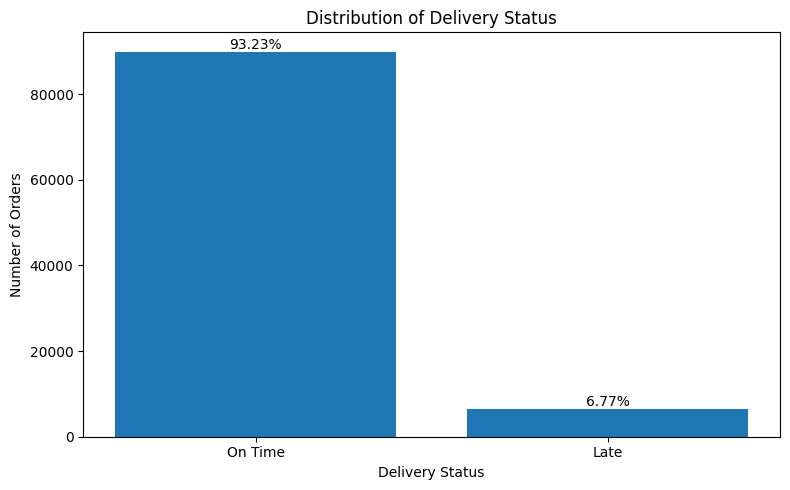

In [133]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_summary["delivery_status"],
    target_summary["count"]
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

for bar, percentage in zip(
    bars,
    target_summary["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Insight

Approximately **93.23%** of the orders were delivered on time, while only **6.77%** were delivered late.

This indicates a strong class imbalance. Therefore, model accuracy alone will not be a reliable evaluation metric because a model could achieve high accuracy by predicting most orders as on time.

Precision, recall, F1-score, confusion matrix, and ROC-AUC will be considered during model evaluation. Stratified data splitting and class-weight techniques will also be investigated during modeling.

## 2. Distribution of Promised Delivery Days

The `promised_delivery_days` feature represents the number of days between the order purchase date and the estimated delivery date.

This variable is examined to understand the typical delivery window promised to customers and to identify possible extreme values.

In [134]:
promised_delivery_summary = (
    modeling_data["promised_delivery_days"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame(name="value")
)

display(promised_delivery_summary)

,value
count,96469.000000
mean,24.372793
std,8.758456
min,3.000000
1%,7.000000
5%,11.000000
25%,19.000000
50%,24.000000
75%,29.000000
95%,39.000000


In [135]:
promised_delivery_stats = pd.Series({
    "mean": modeling_data["promised_delivery_days"].mean(),
    "median": modeling_data["promised_delivery_days"].median(),
    "standard_deviation": modeling_data["promised_delivery_days"].std(),
    "skewness": modeling_data["promised_delivery_days"].skew(),
    "minimum": modeling_data["promised_delivery_days"].min(),
    "maximum": modeling_data["promised_delivery_days"].max()
}).round(2)

display(
    promised_delivery_stats.to_frame(
        name="value"
    )
)

,value
mean,24.37
median,24.00
standard_deviation,8.76
skewness,0.91
minimum,3.00
maximum,156.00


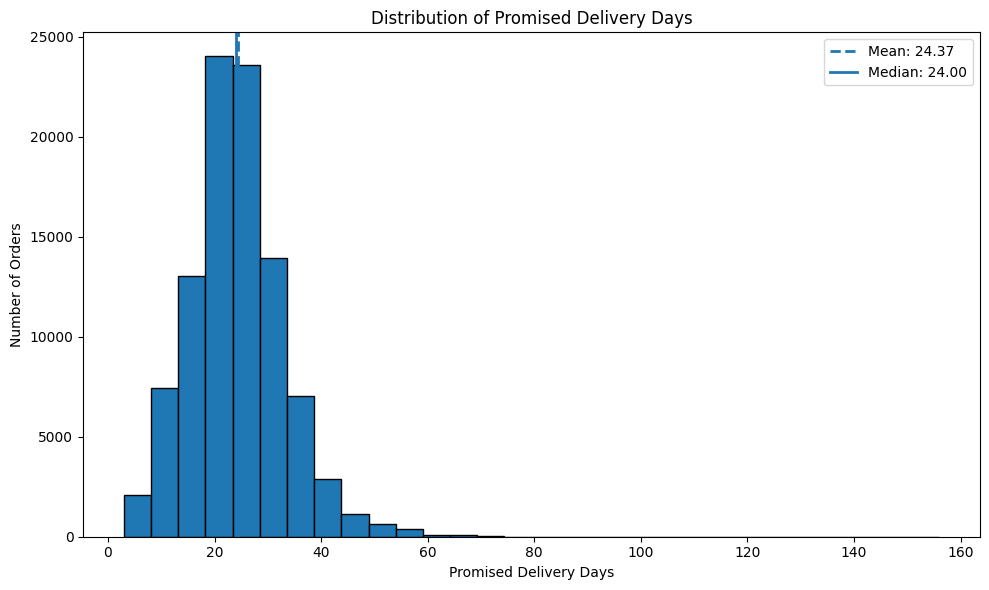

In [136]:
plt.figure(figsize=(10, 6))

plt.hist(
    modeling_data["promised_delivery_days"],
    bins=30,
    edgecolor="black"
)

mean_value = modeling_data["promised_delivery_days"].mean()
median_value = modeling_data["promised_delivery_days"].median()

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_value:.2f}"
)

plt.title("Distribution of Promised Delivery Days")
plt.xlabel("Promised Delivery Days")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()

### Insight

Most orders were assigned a promised delivery window around the median value shown in the statistical summary.

The distribution is right-skewed if the mean is greater than the median, indicating that a small number of orders have unusually long estimated delivery windows.

These extreme values should not be removed automatically because they may represent long-distance deliveries or operational differences between regions.

## 3. Promised Delivery Days by Delivery Status

This analysis compares the promised delivery window between orders delivered on time and orders delivered late.

A box plot and grouped statistical summary are used to examine whether the length of the promised delivery period is associated with delivery delay.

In [137]:
promised_days_by_status = (
    modeling_data
    .assign(
        delivery_status=modeling_data["is_late"].map({
            0: "On Time",
            1: "Late"
        })
    )
    .groupby("delivery_status")["promised_delivery_days"]
    .agg(
        order_count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

display(promised_days_by_status)

,order_count,mean,median,standard_deviation,minimum,maximum
delivery_status,,,,,,
Late,6533,23.29,23.0,7.57,3,70
On Time,89936,24.45,24.0,8.83,3,156


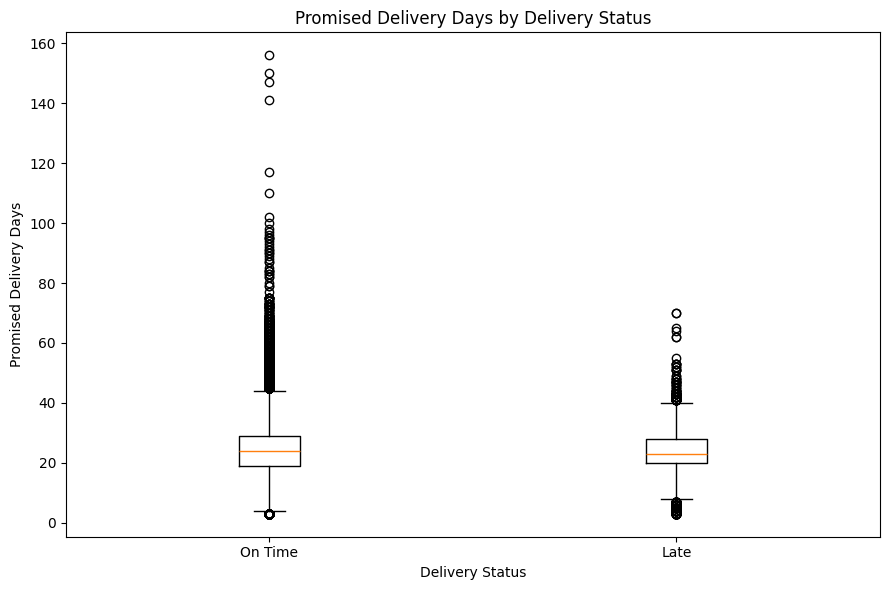

In [138]:
on_time_days = modeling_data.loc[
    modeling_data["is_late"] == 0,
    "promised_delivery_days"
]

late_days = modeling_data.loc[
    modeling_data["is_late"] == 1,
    "promised_delivery_days"
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    [on_time_days, late_days],
    tick_labels=["On Time", "Late"],
    showfliers=True
)

plt.title("Promised Delivery Days by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Promised Delivery Days")
plt.tight_layout()
plt.show()

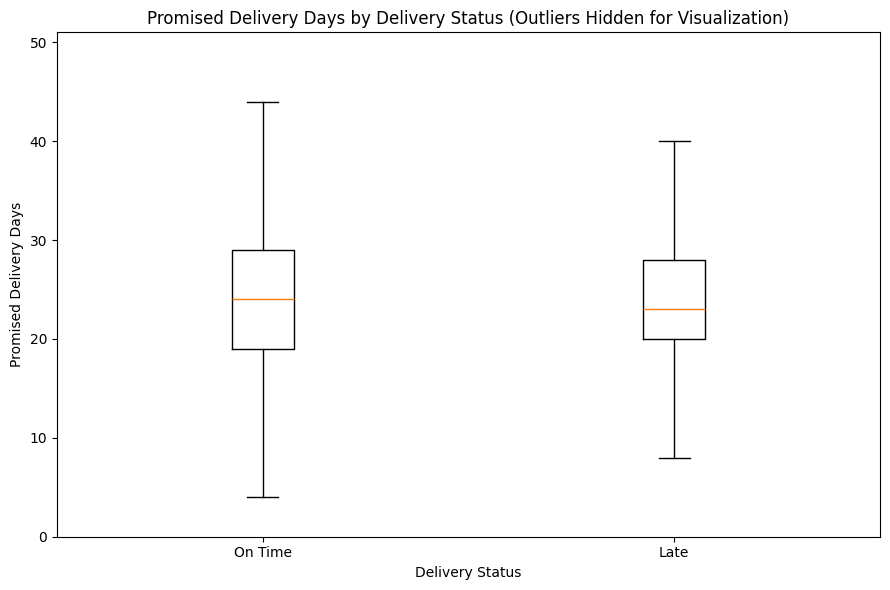

In [139]:
promised_days_upper_limit = (
    modeling_data["promised_delivery_days"]
    .quantile(0.99)
)

plt.figure(figsize=(9, 6))

plt.boxplot(
    [on_time_days, late_days],
    tick_labels=["On Time", "Late"],
    showfliers=False
)

plt.ylim(
    0,
    promised_days_upper_limit
)

plt.title(
    "Promised Delivery Days by Delivery Status "
    "(Outliers Hidden for Visualization)"
)
plt.xlabel("Delivery Status")
plt.ylabel("Promised Delivery Days")
plt.tight_layout()
plt.show()

### Insight

The promised delivery window differs between on-time and late orders.

The median and distribution should be compared carefully to determine whether shorter or longer promised delivery periods are associated with a higher delay risk.

The visible outliers represent orders with unusually long estimated delivery windows. They were retained because they may reflect geographical or operational differences rather than data errors.

## 4. Delivery Delay Trend Over Time

This analysis examines how the monthly delivery-delay rate changed over time.

The number of orders and the percentage of late orders are calculated for each purchase month to identify seasonal or operational patterns.

In [140]:
modeling_data["purchase_year_month"] = (
    modeling_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [141]:
monthly_delay_summary = (
    modeling_data
    .groupby("purchase_year_month")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

monthly_delay_summary["late_rate_percentage"] = (
    monthly_delay_summary["late_orders"]
    / monthly_delay_summary["total_orders"]
    * 100
).round(2)

display(monthly_delay_summary.head(10))

,purchase_year_month,total_orders,late_orders,late_rate_percentage
0,2016-10,265,2,0.75
1,2016-12,1,0,0.00
2,2017-01,750,22,2.93
3,2017-02,1653,49,2.96
4,2017-03,2546,116,4.56
5,2017-04,2303,151,6.56
6,2017-05,3545,106,2.99
7,2017-06,3135,95,3.03
8,2017-07,3872,108,2.79
9,2017-08,4193,122,2.91


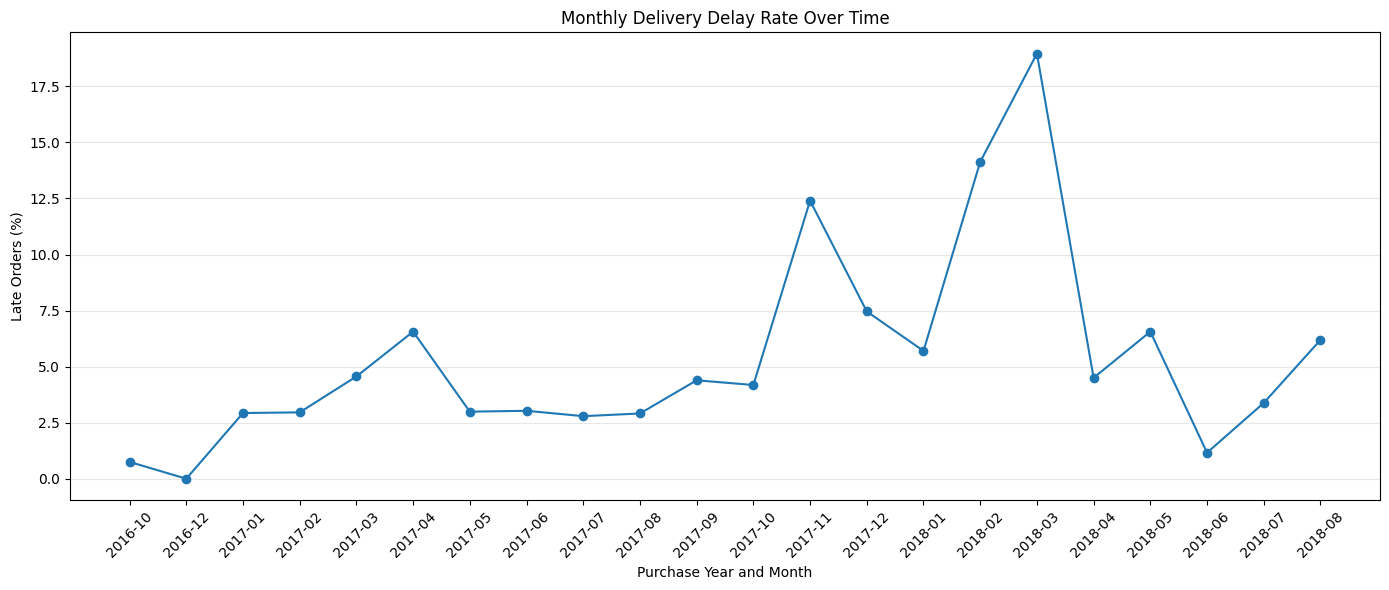

In [142]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_delay_summary["purchase_year_month"],
    monthly_delay_summary["late_rate_percentage"],
    marker="o"
)

plt.title("Monthly Delivery Delay Rate Over Time")
plt.xlabel("Purchase Year and Month")
plt.ylabel("Late Orders (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
highest_delay_months = (
    monthly_delay_summary
    .sort_values(
        "late_rate_percentage",
        ascending=False
    )
    .head(10)
)

display(highest_delay_months)

,purchase_year_month,total_orders,late_orders,late_rate_percentage
16,2018-03,7003,1328,18.96
15,2018-02,6555,926,14.13
12,2017-11,7288,904,12.40
13,2017-12,5513,411,7.46
5,2017-04,2303,151,6.56
18,2018-05,6749,443,6.56
21,2018-08,6351,393,6.19
14,2018-01,7069,403,5.70
4,2017-03,2546,116,4.56
17,2018-04,6798,306,4.50


In [144]:
display(
    monthly_delay_summary
    .sort_values("total_orders")
    .head(10)
)

,purchase_year_month,total_orders,late_orders,late_rate_percentage
1,2016-12,1,0,0.00
0,2016-10,265,2,0.75
2,2017-01,750,22,2.93
3,2017-02,1653,49,2.96
5,2017-04,2303,151,6.56
4,2017-03,2546,116,4.56
7,2017-06,3135,95,3.03
6,2017-05,3545,106,2.99
8,2017-07,3872,108,2.79
10,2017-09,4150,182,4.39


### Insight

The delivery-delay rate changes across different months, indicating that delivery performance is not constant over time.

Months with the highest delay rates should be interpreted together with their total number of orders, because months with very few orders may produce unstable percentages.

The observed fluctuations may be related to seasonal demand, holidays, logistics capacity, or incomplete data coverage during the first and final months of the dataset.

## 5. Order Price by Delivery Status

This analysis examines whether order value is associated with delivery delay.

The distribution of `total_item_price` is compared between on-time and late orders using grouped statistical summaries and a box plot.

Extreme values are retained because expensive orders may be valid business transactions rather than data errors.

In [145]:
price_by_delivery_status = (
    modeling_data
    .assign(
        delivery_status=modeling_data["is_late"].map({
            0: "On Time",
            1: "Late"
        })
    )
    .groupby("delivery_status")["total_item_price"]
    .agg(
        order_count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

display(price_by_delivery_status)

,order_count,mean,median,standard_deviation,minimum,maximum
delivery_status,,,,,,
Late,6533,150.89,90.00,229.65,3.54,6729.0
On Time,89936,136.03,85.39,207.44,0.85,13440.0


In [146]:
price_upper_limit = (
    modeling_data["total_item_price"]
    .quantile(0.99)
)

print(
    "99th percentile of total item price:",
    round(price_upper_limit, 2)
)

99th percentile of total item price: 990.0


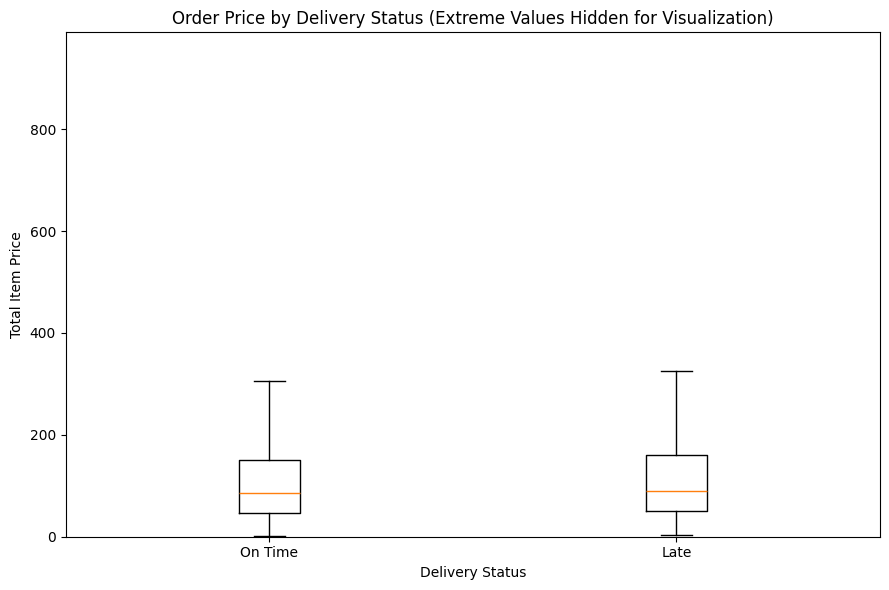

In [147]:
on_time_prices = modeling_data.loc[
    modeling_data["is_late"] == 0,
    "total_item_price"
]

late_prices = modeling_data.loc[
    modeling_data["is_late"] == 1,
    "total_item_price"
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    [on_time_prices, late_prices],
    tick_labels=["On Time", "Late"],
    showfliers=False
)

plt.ylim(0, price_upper_limit)

plt.title(
    "Order Price by Delivery Status "
    "(Extreme Values Hidden for Visualization)"
)
plt.xlabel("Delivery Status")
plt.ylabel("Total Item Price")
plt.tight_layout()
plt.show()

In [148]:
modeling_data["price_segment"] = pd.qcut(
    modeling_data["total_item_price"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

In [149]:
price_segment_summary = (
    modeling_data
    .groupby(
        "price_segment",
        observed=False
    )
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        average_order_price=("total_item_price", "mean")
    )
    .reset_index()
)

price_segment_summary["late_rate_percentage"] = (
    price_segment_summary["late_orders"]
    / price_segment_summary["total_orders"]
    * 100
).round(2)

price_segment_summary["average_order_price"] = (
    price_segment_summary["average_order_price"]
    .round(2)
)

display(price_segment_summary)

,price_segment,total_orders,late_orders,average_order_price,late_rate_percentage
0,Low,24242,1436,28.60,5.92
1,Medium,23995,1607,63.82,6.70
2,High,24331,1662,114.92,6.83
3,Very High,23901,1828,343.05,7.65


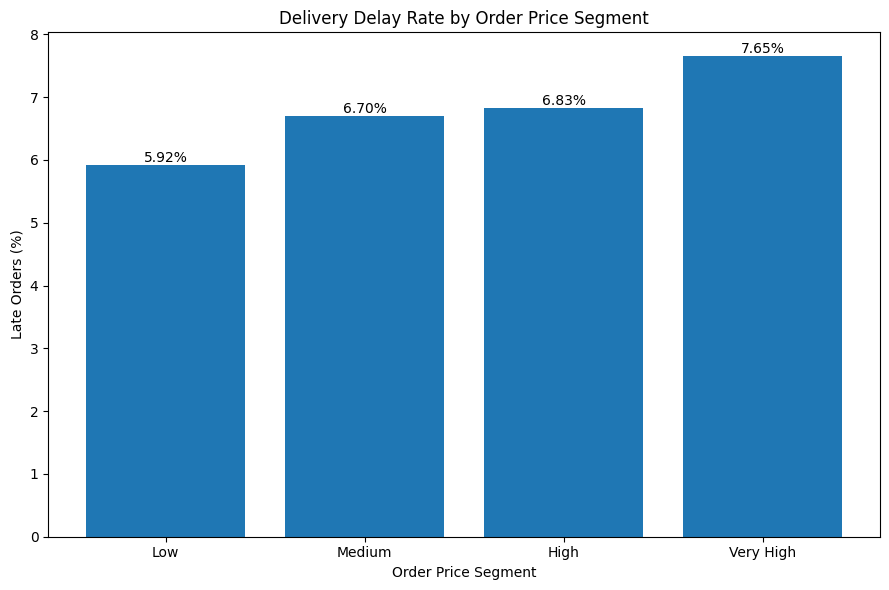

In [150]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    price_segment_summary["price_segment"].astype(str),
    price_segment_summary["late_rate_percentage"]
)

plt.title("Delivery Delay Rate by Order Price Segment")
plt.xlabel("Order Price Segment")
plt.ylabel("Late Orders (%)")

for bar, rate in zip(
    bars,
    price_segment_summary["late_rate_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Insight

Order prices are strongly right-skewed, with a small number of orders having substantially higher values than most transactions.

The median order prices and delay rates across the four price segments should be compared to determine whether higher-value orders experience greater delivery risk.

Any visible difference represents an association and does not, by itself, prove that order price directly causes delivery delays.

## 6. Freight Cost, Order Price, and Delivery Delay

This analysis investigates whether freight cost is associated with order value and delivery delay.

A scatter plot is used to examine the relationship between total item price and total freight cost, while grouped statistics compare freight costs between on-time and late orders.

In [152]:
freight_by_delivery_status = (
    modeling_data
    .assign(
        delivery_status=modeling_data["is_late"].map({
            0: "On Time",
            1: "Late"
        })
    )
    .groupby("delivery_status")["total_freight_value"]
    .agg(
        order_count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

display(freight_by_delivery_status)

,order_count,mean,median,standard_deviation,minimum,maximum
delivery_status,,,,,,
Late,6533,25.25,18.23,23.72,0.0,711.33
On Time,89936,22.61,17.06,21.38,0.0,1794.96


In [153]:
modeling_data["freight_to_price_ratio"] = (
    modeling_data["total_freight_value"]
    / modeling_data["total_item_price"]
)

display(
    modeling_data[
        [
            "total_item_price",
            "total_freight_value",
            "freight_to_price_ratio"
        ]
    ].head()
)

,total_item_price,total_freight_value,freight_to_price_ratio
0,29.99,8.72,0.290764
1,118.70,22.76,0.191744
2,159.90,19.22,0.120200
3,45.00,27.20,0.604444
4,19.90,8.72,0.438191


In [154]:
print(
    "Infinite freight ratios:",
    np.isinf(
        modeling_data["freight_to_price_ratio"]
    ).sum()
)

print(
    "Missing freight ratios:",
    modeling_data["freight_to_price_ratio"]
    .isnull()
    .sum()
)

Infinite freight ratios: 0
Missing freight ratios: 0


In [155]:
scatter_sample = modeling_data.sample(
    n=min(10000, len(modeling_data)),
    random_state=42
)

print("Scatter plot sample size:", scatter_sample.shape[0])

Scatter plot sample size: 10000


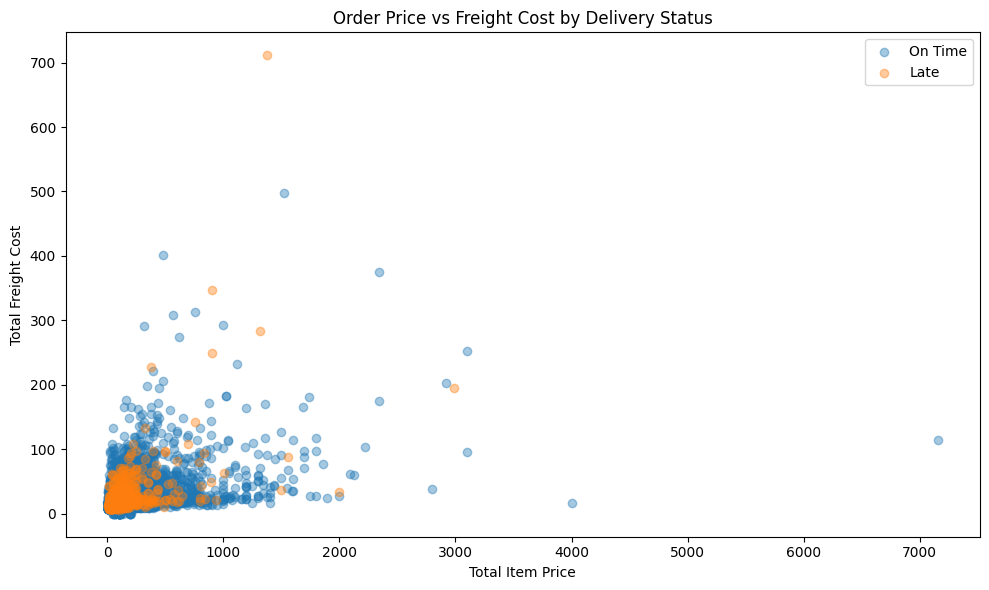

In [156]:
plt.figure(figsize=(10, 6))

for status, label in [
    (0, "On Time"),
    (1, "Late")
]:
    status_data = scatter_sample.loc[
        scatter_sample["is_late"] == status
    ]

    plt.scatter(
        status_data["total_item_price"],
        status_data["total_freight_value"],
        alpha=0.4,
        label=label
    )

plt.title("Order Price vs Freight Cost by Delivery Status")
plt.xlabel("Total Item Price")
plt.ylabel("Total Freight Cost")
plt.legend()
plt.tight_layout()
plt.show()

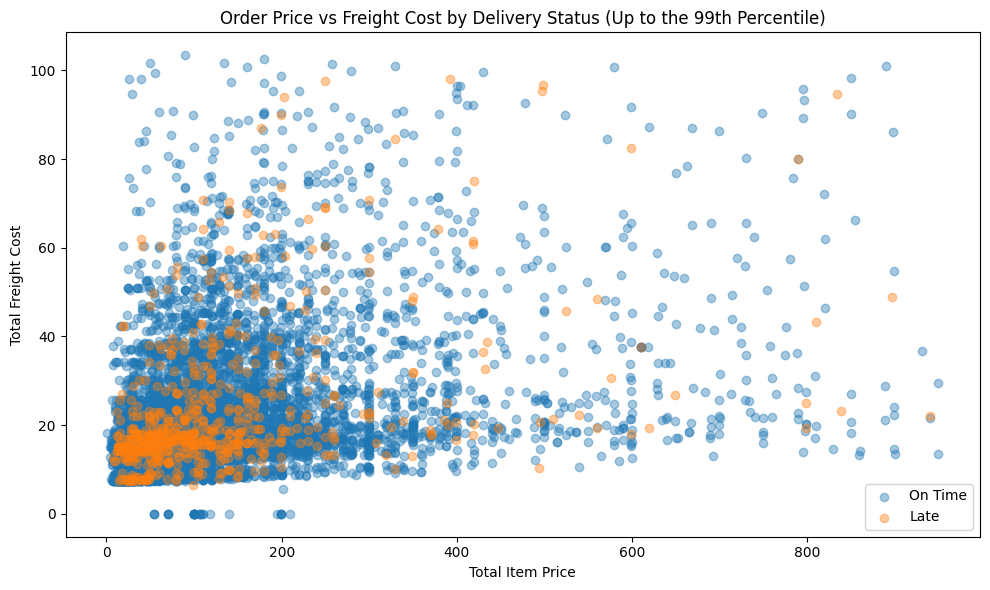

In [157]:
price_limit = modeling_data["total_item_price"].quantile(0.99)
freight_limit = modeling_data["total_freight_value"].quantile(0.99)

filtered_scatter_sample = scatter_sample.loc[
    (scatter_sample["total_item_price"] <= price_limit)
    & (
        scatter_sample["total_freight_value"]
        <= freight_limit
    )
]

plt.figure(figsize=(10, 6))

for status, label in [
    (0, "On Time"),
    (1, "Late")
]:
    status_data = filtered_scatter_sample.loc[
        filtered_scatter_sample["is_late"] == status
    ]

    plt.scatter(
        status_data["total_item_price"],
        status_data["total_freight_value"],
        alpha=0.4,
        label=label
    )

plt.title(
    "Order Price vs Freight Cost by Delivery Status "
    "(Up to the 99th Percentile)"
)
plt.xlabel("Total Item Price")
plt.ylabel("Total Freight Cost")
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
freight_ratio_by_status = (
    modeling_data
    .assign(
        delivery_status=modeling_data["is_late"].map({
            0: "On Time",
            1: "Late"
        })
    )
    .groupby("delivery_status")[
        "freight_to_price_ratio"
    ]
    .agg(
        mean="mean",
        median="median",
        standard_deviation="std"
    )
    .round(3)
)

display(freight_ratio_by_status)

,mean,median,standard_deviation
delivery_status,,,
Late,0.319,0.228,0.321
On Time,0.308,0.224,0.311


### Insight

Freight cost generally increases as the total order price increases, although the relationship contains substantial variation.

The grouped statistics should be used to compare freight costs and freight-to-price ratios between on-time and late orders.

A higher freight-to-price ratio may indicate long-distance delivery, low-value orders with relatively expensive shipping, or operational differences. However, this relationship represents association rather than direct causation.

Extreme values were retained in the dataset and excluded only from the second visualization to improve readability.

## 7. Correlation Analysis of Numerical Features

A correlation matrix is used to examine the strength and direction of relationships between numerical variables.

Spearman correlation is used because several numerical variables are right-skewed and contain valid extreme values.

Correlation does not prove causation, but it can help identify related variables and potentially redundant features.

In [159]:
correlation_columns = [
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "is_weekend",
    "promised_delivery_days",
    "total_payment_value",
    "maximum_installments",
    "payment_records_count",
    "item_count",
    "unique_products",
    "unique_sellers",
    "total_item_price",
    "total_freight_value",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "freight_to_price_ratio",
    "is_late"
]

In [160]:
correlation_matrix = (
    modeling_data[correlation_columns]
    .corr(method="spearman")
)

display(correlation_matrix.round(2))

,purchase_month,purchase_day_of_week,purchase_hour,is_weekend,promised_delivery_days,total_payment_value,maximum_installments,payment_records_count,item_count,unique_products,unique_sellers,total_item_price,total_freight_value,total_product_weight_g,total_product_volume_cm3,freight_to_price_ratio,is_late
purchase_month,1.00,0.02,0.00,0.01,-0.11,0.01,0.03,0.00,-0.00,0.01,0.01,0.00,0.00,0.01,0.02,-0.00,-0.04
purchase_day_of_week,0.02,1.00,0.02,0.74,0.08,-0.01,0.03,-0.00,-0.01,0.00,0.01,-0.01,0.00,0.00,0.00,0.01,-0.01
purchase_hour,0.00,0.02,1.00,0.05,0.00,0.01,0.03,0.01,-0.01,0.00,-0.00,0.01,0.00,0.01,0.01,-0.01,0.01
is_weekend,0.01,0.74,0.05,1.00,0.04,-0.00,0.03,-0.01,-0.01,0.00,0.01,-0.00,0.00,0.00,0.01,0.01,-0.01
promised_delivery_days,-0.11,0.08,0.00,0.04,1.00,0.17,0.10,0.01,0.01,0.02,0.02,0.12,0.46,0.08,0.07,0.14,-0.02
total_payment_value,0.01,-0.01,0.01,-0.00,0.17,1.00,0.38,-0.01,0.22,0.14,0.10,0.99,0.57,0.56,0.44,-0.71,0.03
maximum_installments,0.03,0.03,0.03,0.03,0.10,0.38,1.00,-0.06,0.06,0.06,0.05,0.37,0.23,0.23,0.17,-0.26,0.01
payment_records_count,0.00,-0.00,0.01,-0.01,0.01,-0.01,-0.06,1.00,-0.00,0.01,0.01,-0.01,0.01,0.01,0.01,0.02,-0.00
item_count,-0.00,-0.01,-0.01,-0.01,0.01,0.22,0.06,-0.00,1.00,0.55,0.35,0.18,0.38,0.19,0.20,0.08,-0.02
unique_products,0.01,0.00,0.00,0.00,0.02,0.14,0.06,0.01,0.55,1.00,0.63,0.11,0.21,0.10,0.09,0.03,-0.02


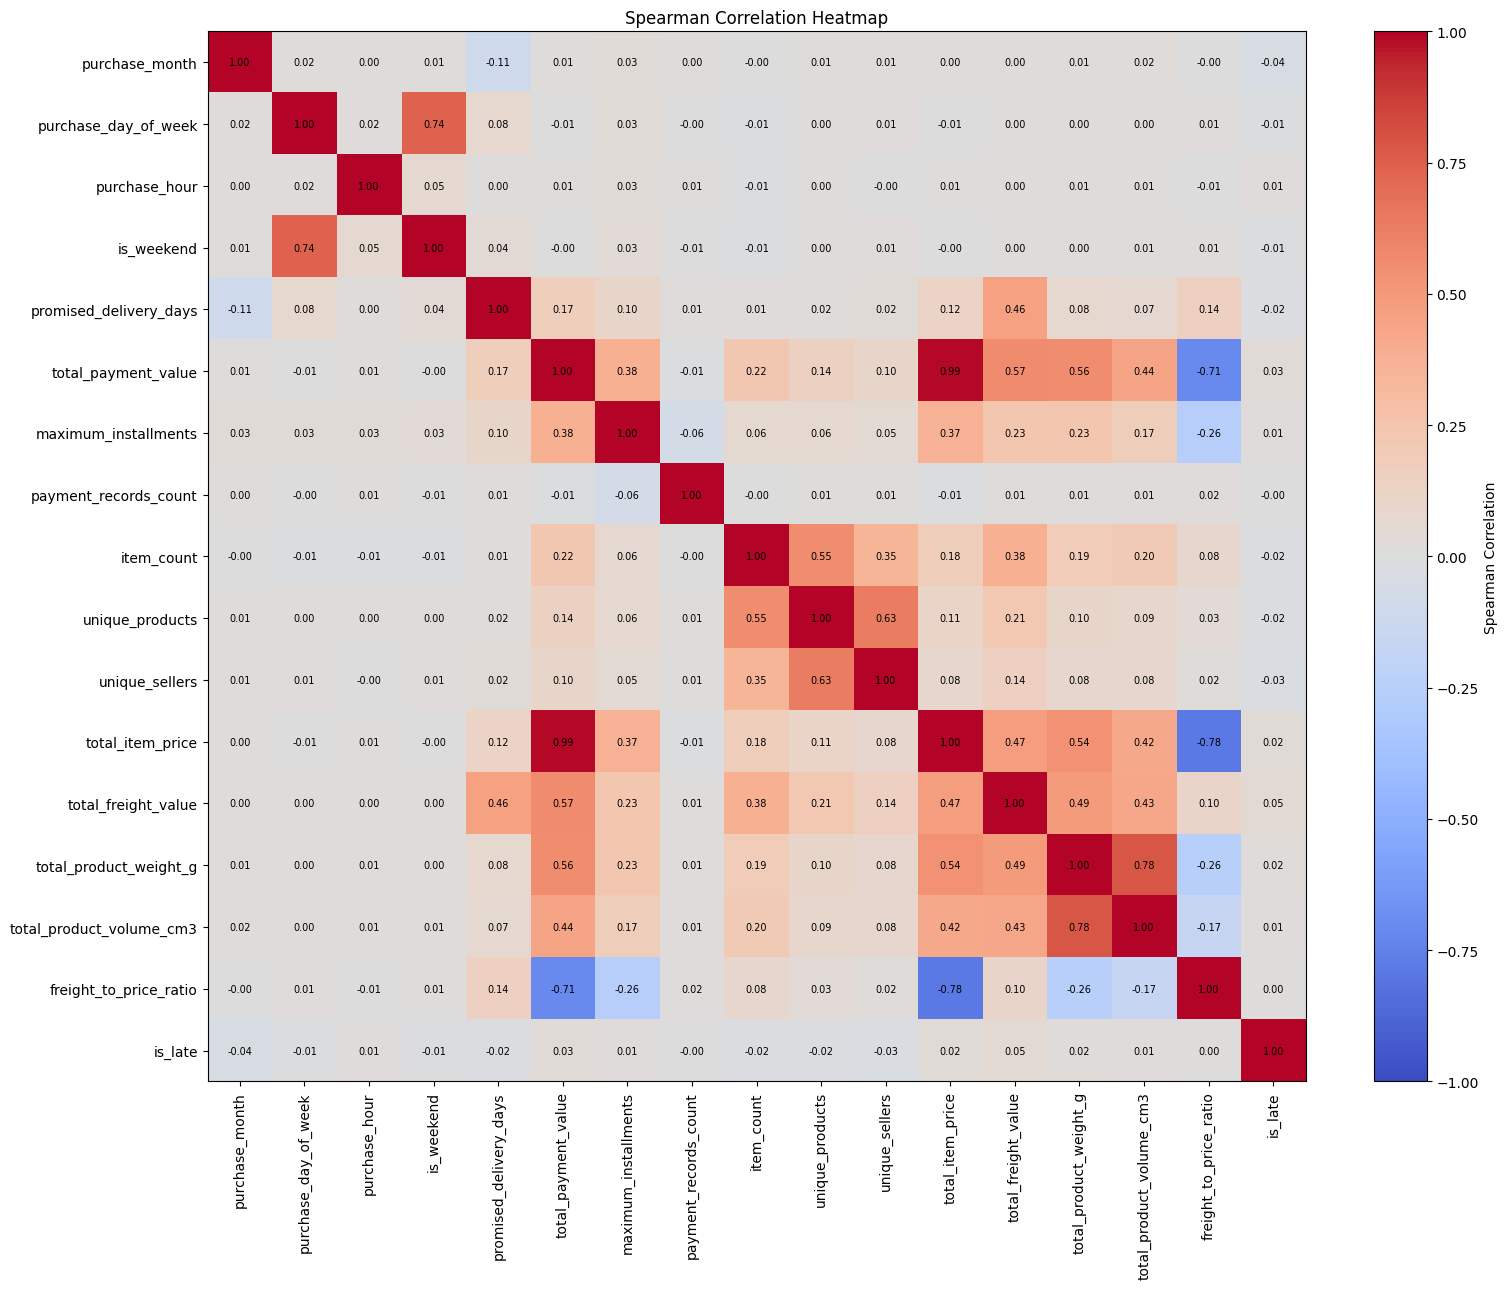

In [161]:
plt.figure(figsize=(16, 13))

heatmap = plt.imshow(
    correlation_matrix,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    heatmap,
    label="Spearman Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        value = correlation_matrix.iloc[row, column]

        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

In [162]:
target_correlations = (
    correlation_matrix["is_late"]
    .drop("is_late")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
    .to_frame(name="correlation_with_is_late")
)

display(target_correlations)

,correlation_with_is_late
total_freight_value,0.052421
purchase_month,-0.039612
total_payment_value,0.029177
unique_sellers,-0.026498
total_item_price,0.024023
promised_delivery_days,-0.022483
unique_products,-0.021832
item_count,-0.019793
total_product_weight_g,0.016436
maximum_installments,0.012367


In [163]:
high_correlation_pairs = []

for row_index in range(len(correlation_columns)):
    for column_index in range(row_index + 1, len(correlation_columns)):

        first_feature = correlation_columns[row_index]
        second_feature = correlation_columns[column_index]

        correlation_value = correlation_matrix.loc[
            first_feature,
            second_feature
        ]

        if abs(correlation_value) >= 0.80:
            high_correlation_pairs.append({
                "first_feature": first_feature,
                "second_feature": second_feature,
                "correlation": round(correlation_value, 3)
            })

high_correlation_pairs_df = pd.DataFrame(
    high_correlation_pairs
)

display(high_correlation_pairs_df)

,first_feature,second_feature,correlation
0,total_payment_value,total_item_price,0.99


### Insight

The correlation matrix shows that some order-related variables are strongly associated with each other, particularly features representing order value, payment value, product quantity, freight cost, and physical product characteristics.

Most individual numerical features may show only weak correlations with the target variable `is_late`. This does not necessarily mean they are useless, because delivery delays may depend on nonlinear interactions between multiple features.

Highly correlated predictors will be reviewed during feature selection to reduce redundancy and prevent unnecessary model complexity.

## 8. Delivery Delay by Customer State

This analysis examines whether delivery performance varies across customer states.

Both order volume and late-delivery rate are considered because states with very few orders may produce unstable or misleading percentages.

In [165]:
customer_state_summary = (
    modeling_data
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

customer_state_summary["late_rate_percentage"] = (
    customer_state_summary["late_orders"]
    / customer_state_summary["total_orders"]
    * 100
).round(2)

customer_state_summary = customer_state_summary.sort_values(
    "total_orders",
    ascending=False
)

display(customer_state_summary)

,customer_state,total_orders,late_orders,late_rate_percentage
25,sp,40493,1819,4.49
18,rj,12350,1495,12.11
10,mg,11354,519,4.57
22,rs,5344,325,6.08
17,pr,4923,199,4.04
23,sc,3546,291,8.21
4,ba,3256,396,12.16
6,df,2080,118,5.67
7,es,1995,214,10.73
8,go,1957,128,6.54


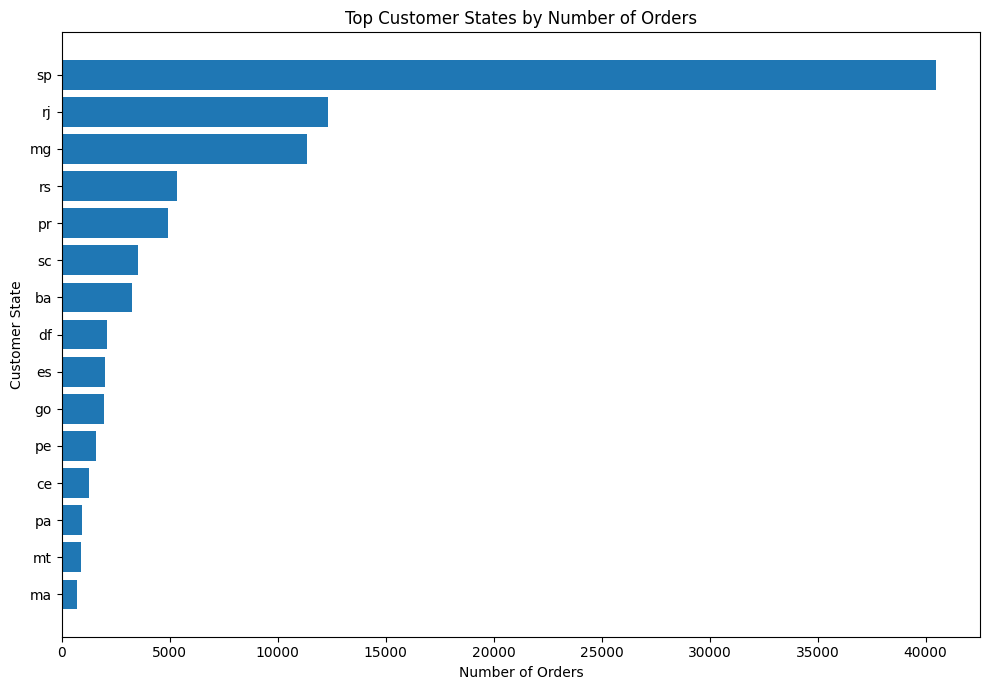

In [166]:
top_customer_states = (
    customer_state_summary
    .head(15)
    .sort_values(
        "total_orders",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_customer_states["customer_state"],
    top_customer_states["total_orders"]
)

plt.title("Top Customer States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

In [168]:
minimum_orders = 500

reliable_customer_states = (
    customer_state_summary.loc[
        customer_state_summary["total_orders"]
        >= minimum_orders
    ]
    .sort_values(
        "late_rate_percentage",
        ascending=False
    )
)

display(reliable_customer_states)

,customer_state,total_orders,late_orders,late_rate_percentage
9,ma,717,125,17.43
5,ce,1279,176,13.76
4,ba,3256,396,12.16
18,rj,12350,1495,12.11
13,pa,946,106,11.21
7,es,1995,214,10.73
14,pb,517,54,10.44
11,ms,701,68,9.70
15,pe,1593,153,9.60
23,sc,3546,291,8.21


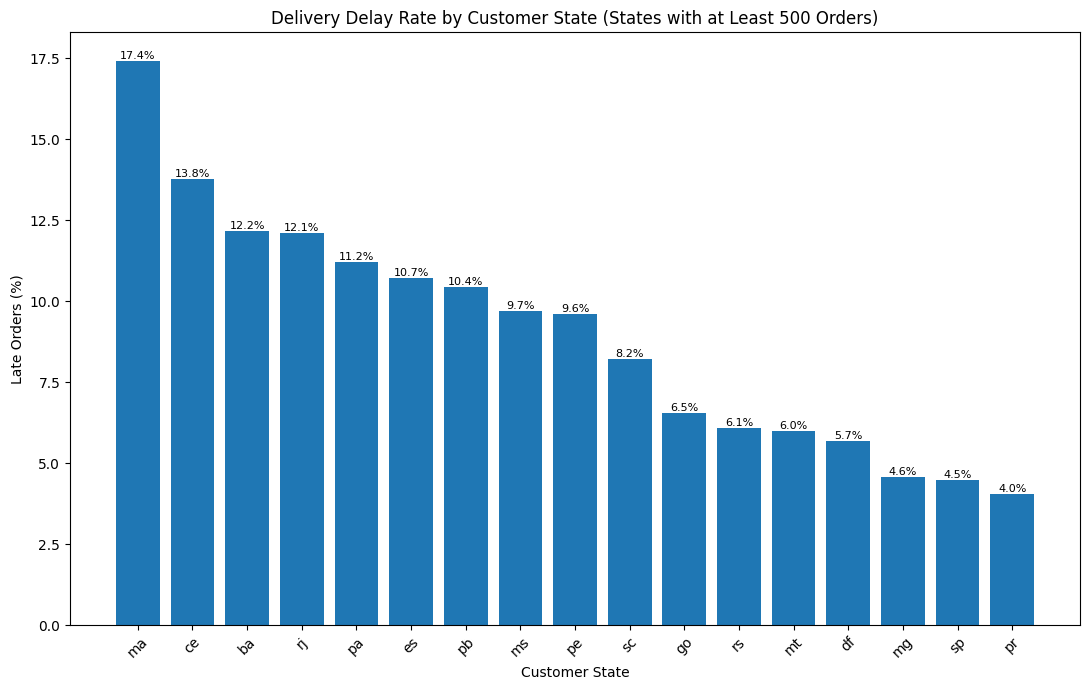

In [169]:
plt.figure(figsize=(11, 7))

bars = plt.bar(
    reliable_customer_states["customer_state"],
    reliable_customer_states["late_rate_percentage"]
)

plt.title(
    f"Delivery Delay Rate by Customer State "
    f"(States with at Least {minimum_orders} Orders)"
)
plt.xlabel("Customer State")
plt.ylabel("Late Orders (%)")
plt.xticks(rotation=45)

for bar, rate in zip(
    bars,
    reliable_customer_states["late_rate_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [170]:
print("States with the highest delay rates:")

display(
    reliable_customer_states[
        [
            "customer_state",
            "total_orders",
            "late_orders",
            "late_rate_percentage"
        ]
    ].head(5)
)

print("States with the lowest delay rates:")

display(
    reliable_customer_states[
        [
            "customer_state",
            "total_orders",
            "late_orders",
            "late_rate_percentage"
        ]
    ].tail(5)
)

States with the highest delay rates:


,customer_state,total_orders,late_orders,late_rate_percentage
9,ma,717,125,17.43
5,ce,1279,176,13.76
4,ba,3256,396,12.16
18,rj,12350,1495,12.11
13,pa,946,106,11.21


States with the lowest delay rates:


,customer_state,total_orders,late_orders,late_rate_percentage
12,mt,886,53,5.98
6,df,2080,118,5.67
10,mg,11354,519,4.57
25,sp,40493,1819,4.49
17,pr,4923,199,4.04


### Insight

Delivery performance varies across customer states, suggesting that geographical location may influence the probability of delay.

The states with the highest delay rates were identified only after applying a minimum order threshold, which reduces the risk of drawing conclusions from very small samples.

These differences may be associated with delivery distance, regional logistics infrastructure, seller concentration, or transportation capacity. However, customer state alone does not explain the cause of delay.

## 9. Delivery Delay by Product Category

This analysis examines whether delivery-delay rates vary across product categories.

Both the number of orders and the late-delivery rate are considered because categories with very few orders may produce unstable percentages.

In [172]:
product_category_summary = (
    modeling_data
    .groupby("main_product_category")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        average_weight_g=("total_product_weight_g", "mean"),
        average_freight_value=("total_freight_value", "mean")
    )
    .reset_index()
)

product_category_summary["late_rate_percentage"] = (
    product_category_summary["late_orders"]
    / product_category_summary["total_orders"]
    * 100
).round(2)

product_category_summary["average_weight_g"] = (
    product_category_summary["average_weight_g"]
    .round(2)
)

product_category_summary["average_freight_value"] = (
    product_category_summary["average_freight_value"]
    .round(2)
)

display(
    product_category_summary
    .sort_values("total_orders", ascending=False)
    .head(20)
)

,main_product_category,total_orders,late_orders,average_weight_g,average_freight_value,late_rate_percentage
7,bed_bath_table,9239,689,2557.05,22.15,7.46
43,health_beauty,8620,648,1151.61,20.79,7.52
65,sports_leisure,7477,493,1918.25,21.77,6.59
15,computers_accessories,6519,417,1062.45,22.21,6.40
39,furniture_decor,6208,446,3500.31,27.23,7.18
49,housewares,5670,308,3842.12,25.07,5.43
71,watches_gifts,5453,406,623.54,17.90,7.45
68,telephony,4071,291,283.02,16.98,7.15
5,auto,3803,278,2832.57,23.86,7.31
69,toys,3758,241,1968.19,20.00,6.41


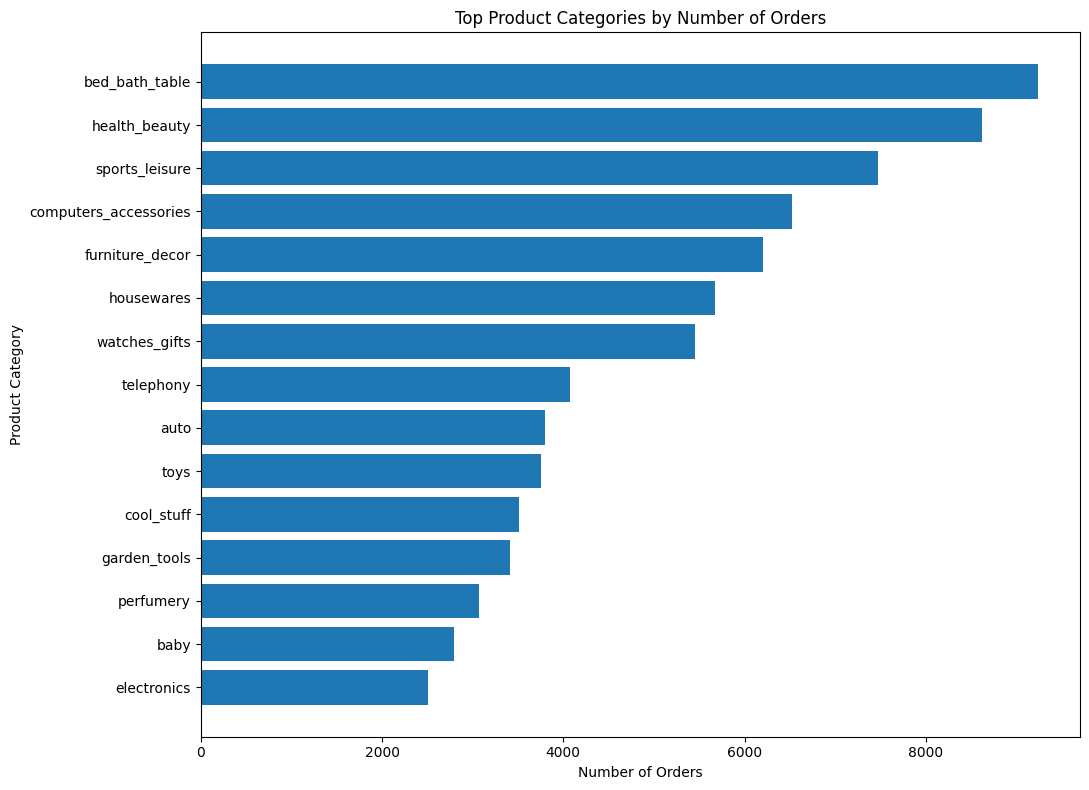

In [173]:
top_categories_by_orders = (
    product_category_summary
    .sort_values("total_orders", ascending=False)
    .head(15)
    .sort_values("total_orders")
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_categories_by_orders["main_product_category"],
    top_categories_by_orders["total_orders"]
)

plt.title("Top Product Categories by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [174]:
minimum_category_orders = 500

reliable_categories = (
    product_category_summary.loc[
        product_category_summary["total_orders"]
        >= minimum_category_orders
    ]
    .sort_values(
        "late_rate_percentage",
        ascending=False
    )
)

display(reliable_categories)

,main_product_category,total_orders,late_orders,average_weight_g,average_freight_value,late_rate_percentage
57,office_furniture,1244,101,15148.97,53.60,8.12
6,baby,2794,226,3504.07,24.20,8.09
26,electronics,2509,192,843.86,18.35,7.65
56,musical_instruments,606,46,3346.93,29.50,7.59
43,health_beauty,8620,648,1151.61,20.79,7.52
7,bed_bath_table,9239,689,2557.05,22.15,7.46
71,watches_gifts,5453,406,623.54,17.90,7.45
17,construction_tools_construction,731,54,3915.11,28.08,7.39
5,auto,3803,278,2832.57,23.86,7.31
39,furniture_decor,6208,446,3500.31,27.23,7.18


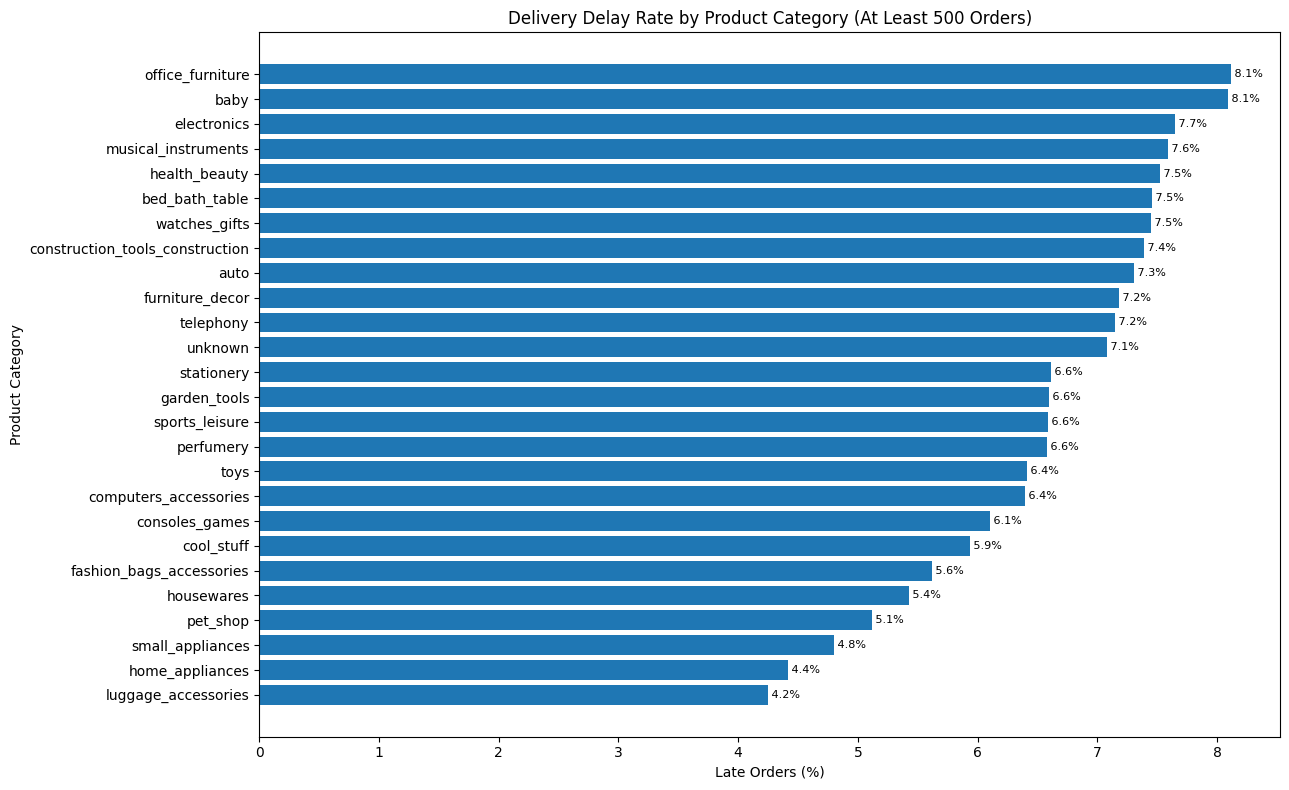

In [175]:
plt.figure(figsize=(13, 8))

categories_for_plot = reliable_categories.sort_values(
    "late_rate_percentage"
)

bars = plt.barh(
    categories_for_plot["main_product_category"],
    categories_for_plot["late_rate_percentage"]
)

plt.title(
    "Delivery Delay Rate by Product Category "
    f"(At Least {minimum_category_orders} Orders)"
)
plt.xlabel("Late Orders (%)")
plt.ylabel("Product Category")

for bar, rate in zip(
    bars,
    categories_for_plot["late_rate_percentage"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [176]:
print("Categories with the highest delay rates:")

display(
    reliable_categories[
        [
            "main_product_category",
            "total_orders",
            "late_orders",
            "late_rate_percentage",
            "average_weight_g",
            "average_freight_value"
        ]
    ].head(10)
)

Categories with the highest delay rates:


,main_product_category,total_orders,late_orders,late_rate_percentage,average_weight_g,average_freight_value
57,office_furniture,1244,101,8.12,15148.97,53.60
6,baby,2794,226,8.09,3504.07,24.20
26,electronics,2509,192,7.65,843.86,18.35
56,musical_instruments,606,46,7.59,3346.93,29.50
43,health_beauty,8620,648,7.52,1151.61,20.79
7,bed_bath_table,9239,689,7.46,2557.05,22.15
71,watches_gifts,5453,406,7.45,623.54,17.90
17,construction_tools_construction,731,54,7.39,3915.11,28.08
5,auto,3803,278,7.31,2832.57,23.86
39,furniture_decor,6208,446,7.18,3500.31,27.23


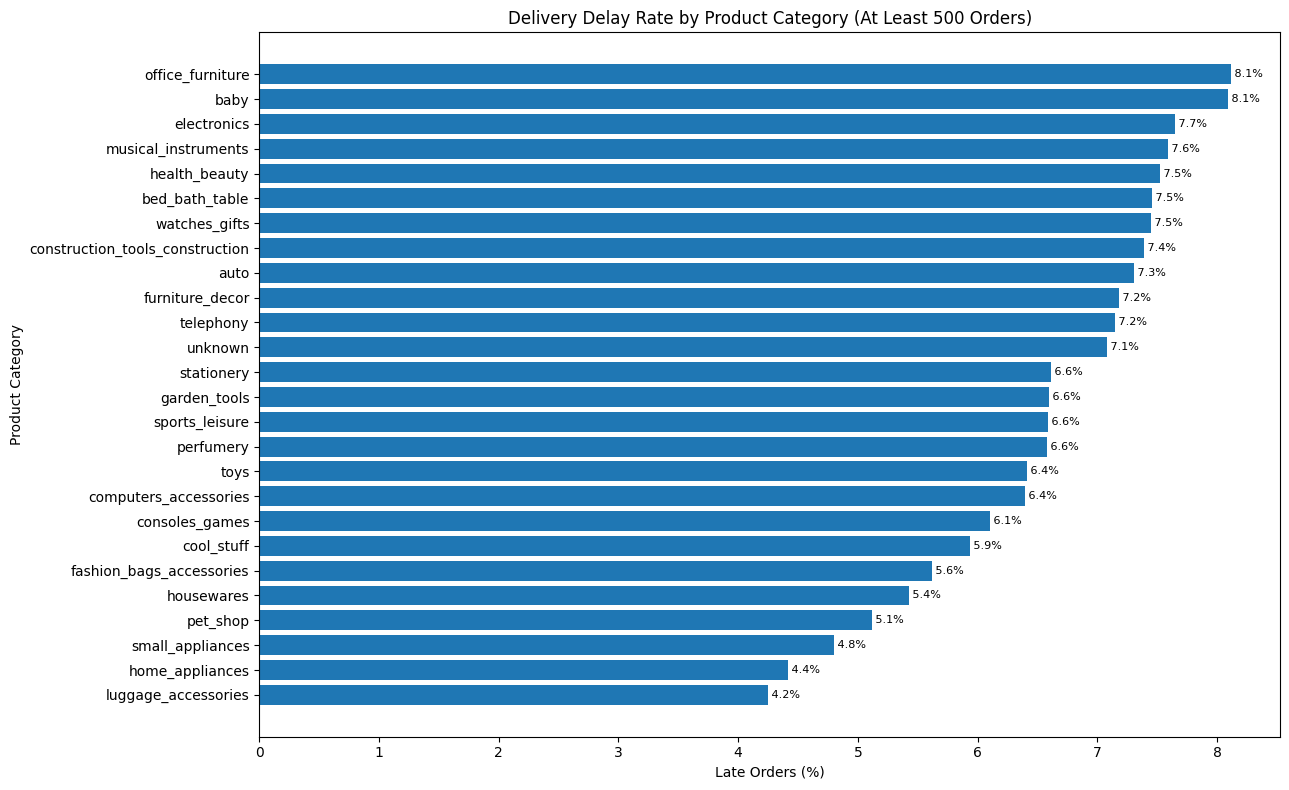

In [177]:
plt.figure(figsize=(13, 8))

categories_for_plot = reliable_categories.sort_values(
    "late_rate_percentage"
)

bars = plt.barh(
    categories_for_plot["main_product_category"],
    categories_for_plot["late_rate_percentage"]
)

plt.title(
    "Delivery Delay Rate by Product Category "
    f"(At Least {minimum_category_orders} Orders)"
)
plt.xlabel("Late Orders (%)")
plt.ylabel("Product Category")

for bar, rate in zip(
    bars,
    categories_for_plot["late_rate_percentage"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [178]:
print("Categories with the highest delay rates:")

display(
    reliable_categories[
        [
            "main_product_category",
            "total_orders",
            "late_orders",
            "late_rate_percentage",
            "average_weight_g",
            "average_freight_value"
        ]
    ].head(10)
)

Categories with the highest delay rates:


,main_product_category,total_orders,late_orders,late_rate_percentage,average_weight_g,average_freight_value
57,office_furniture,1244,101,8.12,15148.97,53.60
6,baby,2794,226,8.09,3504.07,24.20
26,electronics,2509,192,7.65,843.86,18.35
56,musical_instruments,606,46,7.59,3346.93,29.50
43,health_beauty,8620,648,7.52,1151.61,20.79
7,bed_bath_table,9239,689,7.46,2557.05,22.15
71,watches_gifts,5453,406,7.45,623.54,17.90
17,construction_tools_construction,731,54,7.39,3915.11,28.08
5,auto,3803,278,7.31,2832.57,23.86
39,furniture_decor,6208,446,7.18,3500.31,27.23


In [179]:
print("Categories with the lowest delay rates:")

display(
    reliable_categories[
        [
            "main_product_category",
            "total_orders",
            "late_orders",
            "late_rate_percentage",
            "average_weight_g",
            "average_freight_value"
        ]
    ].tail(10)
)

Categories with the lowest delay rates:


,main_product_category,total_orders,late_orders,late_rate_percentage,average_weight_g,average_freight_value
69,toys,3758,241,6.41,1968.19,20.00
15,computers_accessories,6519,417,6.40,1062.45,22.21
16,consoles_games,1016,62,6.10,487.97,18.84
20,cool_stuff,3516,209,5.94,2681.53,23.09
28,fashion_bags_accessories,1816,102,5.62,414.40,16.93
49,housewares,5670,308,5.43,3842.12,25.07
60,pet_shop,1679,86,5.12,3369.68,23.18
63,small_appliances,604,29,4.80,3171.17,25.22
44,home_appliances,747,33,4.42,1951.96,19.37
53,luggage_accessories,1011,43,4.25,6169.33,29.74


### Insight

Delivery-delay rates vary across product categories, suggesting that the type of product may influence logistics performance.

The comparison was restricted to categories with at least 500 orders to avoid drawing conclusions from very small samples.

Categories with higher delay rates may also have higher average weight, freight cost, special handling requirements, or different seller-location patterns. Therefore, product category may be useful when combined with other order and logistics features, but it should not be interpreted as the direct cause of delay.